In [1]:
#importing basic packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Loading the data
data = pd.read_csv('Machine Downtime.csv')
data.head()

,Date,Machine_ID,Assembly_Line_No,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(°C),Spindle_Bearing_Temperature(°C),Spindle_Vibration(µm),Tool_Vibration(µm),Spindle_Speed(RPM),Voltage(volts),Torque(Nm),Cutting(kN),Downtime
0,31-12-2021,Makino-L1-Unit1-2013,Shopfloor-L1,71.04,6.933725,6.284965,25.6,46.0,33.4,1.291,26.492,25892.0,335.0,24.055326,3.58,Machine_Failure
1,31-12-2021,Makino-L1-Unit1-2013,Shopfloor-L1,125.33,4.936892,6.196733,35.3,47.4,34.6,1.382,25.274,19856.0,368.0,14.202890,2.68,Machine_Failure
2,31-12-2021,Makino-L3-Unit1-2015,Shopfloor-L3,71.12,6.839413,6.655448,13.1,40.7,33.0,1.319,30.608,19851.0,325.0,24.049267,3.55,Machine_Failure
3,31-05-2022,Makino-L2-Unit1-2015,Shopfloor-L2,139.34,4.574382,6.560394,24.4,44.2,40.6,0.618,30.791,18461.0,360.0,25.860029,3.55,Machine_Failure
4,31-03-2022,Makino-L1-Unit1-2013,Shopfloor-L1,60.51,6.893182,6.141238,4.1,47.3,31.4,0.983,25.516,26526.0,354.0,25.515874,3.55,Machine_Failure


In [3]:
data.shape

(2500, 16)

In [4]:
sizes = data['Downtime'].value_counts(sort=1)
print(sizes)

Downtime
Machine_Failure       1265
No_Machine_Failure    1235
Name: count, dtype: int64


In [5]:
data.isnull().sum()

Date                                0
Machine_ID                          0
Assembly_Line_No                    0
Hydraulic_Pressure(bar)            10
Coolant_Pressure(bar)              19
Air_System_Pressure(bar)           17
Coolant_Temperature                12
Hydraulic_Oil_Temperature(°C)      16
Spindle_Bearing_Temperature(°C)     7
Spindle_Vibration(µm)              11
Tool_Vibration(µm)                 11
Spindle_Speed(RPM)                  6
Voltage(volts)                      6
Torque(Nm)                         21
Cutting(kN)                         7
Downtime                            0
dtype: int64

In [6]:
data.isnull()

,Date,Machine_ID,Assembly_Line_No,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(°C),Spindle_Bearing_Temperature(°C),Spindle_Vibration(µm),Tool_Vibration(µm),Spindle_Speed(RPM),Voltage(volts),Torque(Nm),Cutting(kN),Downtime
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2496,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2497,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2498,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
data.columns

Index(['Date', 'Machine_ID', 'Assembly_Line_No', 'Hydraulic_Pressure(bar)',
       'Coolant_Pressure(bar)', 'Air_System_Pressure(bar)',
       'Coolant_Temperature', 'Hydraulic_Oil_Temperature(°C)',
       'Spindle_Bearing_Temperature(°C)', 'Spindle_Vibration(µm)',
       'Tool_Vibration(µm)', 'Spindle_Speed(RPM)', 'Voltage(volts)',
       'Torque(Nm)', 'Cutting(kN)', 'Downtime'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             2500 non-null   object 
 1   Machine_ID                       2500 non-null   object 
 2   Assembly_Line_No                 2500 non-null   object 
 3   Hydraulic_Pressure(bar)          2490 non-null   float64
 4   Coolant_Pressure(bar)            2481 non-null   float64
 5   Air_System_Pressure(bar)         2483 non-null   float64
 6   Coolant_Temperature              2488 non-null   float64
 7   Hydraulic_Oil_Temperature(°C)    2484 non-null   float64
 8   Spindle_Bearing_Temperature(°C)  2493 non-null   float64
 9   Spindle_Vibration(µm)            2489 non-null   float64
 10  Tool_Vibration(µm)               2489 non-null   float64
 11  Spindle_Speed(RPM)               2494 non-null   float64
 12  Voltage(volts)      

In [9]:
data['Date'].unique()

array(['31-12-2021', '31-05-2022', '31-03-2022', '31-01-2022',
       '30-12-2021', '30-04-2022', '30-03-2022', '30-01-2022',
       '29-12-2021', '29-05-2022', '29-04-2022', '29-03-2022',
       '29-01-2022', '28-12-2021', '28-04-2022', '28-03-2022',
       '28-02-2022', '28-01-2022', '27-12-2021', '27-05-2022',
       '27-04-2022', '27-03-2022', '27-02-2022', '27-01-2022',
       '26-12-2021', '26-05-2022', '26-04-2022', '26-03-2022',
       '26-02-2022', '26-01-2022', '25-05-2022', '25-04-2022',
       '25-03-2022', '25-02-2022', '25-01-2022', '24-12-2021',
       '24-11-2021', '24-05-2022', '24-04-2022', '24-03-2022',
       '24-02-2022', '24-01-2022', '23-05-2022', '23-04-2022',
       '23-03-2022', '23-02-2022', '23-01-2022', '22-12-2021',
       '22-04-2022', '22-03-2022', '22-02-2022', '22-01-2022',
       '21-12-2021', '21-05-2022', '21-04-2022', '21-03-2022',
       '21-02-2022', '21-01-2022', '20-04-2022', '20-03-2022',
       '20-02-2022', '20-01-2022', '19-06-2022', '19-05

In [10]:
data['Machine_ID'].unique()

array(['Makino-L1-Unit1-2013', 'Makino-L3-Unit1-2015',
       'Makino-L2-Unit1-2015'], dtype=object)

In [11]:
data['Assembly_Line_No'].unique()

array(['Shopfloor-L1', 'Shopfloor-L3', 'Shopfloor-L2'], dtype=object)

In [12]:
data.nunique()

Date                                164
Machine_ID                            3
Assembly_Line_No                      3
Hydraulic_Pressure(bar)            1977
Coolant_Pressure(bar)              1628
Air_System_Pressure(bar)           2472
Coolant_Temperature                 275
Hydraulic_Oil_Temperature(°C)       209
Spindle_Bearing_Temperature(°C)     204
Spindle_Vibration(µm)              1144
Tool_Vibration(µm)                 2350
Spindle_Speed(RPM)                 1180
Voltage(volts)                      238
Torque(Nm)                         1327
Cutting(kN)                         170
Downtime                              2
dtype: int64

In [13]:
data.dtypes

Date                                object
Machine_ID                          object
Assembly_Line_No                    object
Hydraulic_Pressure(bar)            float64
Coolant_Pressure(bar)              float64
Air_System_Pressure(bar)           float64
Coolant_Temperature                float64
Hydraulic_Oil_Temperature(°C)      float64
Spindle_Bearing_Temperature(°C)    float64
Spindle_Vibration(µm)              float64
Tool_Vibration(µm)                 float64
Spindle_Speed(RPM)                 float64
Voltage(volts)                     float64
Torque(Nm)                         float64
Cutting(kN)                        float64
Downtime                            object
dtype: object

In [14]:
data.describe()

,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(°C),Spindle_Bearing_Temperature(°C),Spindle_Vibration(µm),Tool_Vibration(µm),Spindle_Speed(RPM),Voltage(volts),Torque(Nm),Cutting(kN)
count,2490.000000,2481.000000,2483.000000,2488.000000,2484.000000,2493.000000,2489.000000,2489.000000,2494.000000,2494.000000,2479.000000,2493.000000
mean,101.409084,4.947058,6.499275,18.559887,47.618317,35.063698,1.009334,25.411975,20274.792302,348.996792,25.234968,2.782551
std,30.289301,0.997357,0.407279,8.554480,3.768674,3.764823,0.342898,6.437142,3852.660056,45.376024,6.138564,0.616688
min,-14.326454,0.325000,5.063480,4.100000,35.200000,22.600000,-0.461000,2.161000,0.000000,202.000000,0.000000,1.800000
25%,76.355000,4.462464,6.217987,10.400000,45.100000,32.500000,0.777000,21.089000,17919.000000,319.000000,21.666115,2.250000
50%,96.763486,4.939960,6.505191,21.200000,47.700000,35.100000,1.008000,25.455000,20137.500000,349.000000,24.647736,2.780000
75%,126.415727,5.518401,6.780550,25.600000,50.100000,37.600000,1.236000,29.790000,22501.750000,380.000000,30.514008,3.270000
max,191.000000,11.350000,7.973992,98.200000,61.400000,49.500000,2.000000,45.726000,27957.000000,479.000000,55.552400,3.930000


In [15]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(data['Downtime'].values)
data['Downtime'] = le.transform(data['Downtime'].values)

In [16]:
data

,Date,Machine_ID,Assembly_Line_No,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(°C),Spindle_Bearing_Temperature(°C),Spindle_Vibration(µm),Tool_Vibration(µm),Spindle_Speed(RPM),Voltage(volts),Torque(Nm),Cutting(kN),Downtime
0,31-12-2021,Makino-L1-Unit1-2013,Shopfloor-L1,71.040000,6.933725,6.284965,25.6,46.0,33.4,1.291,26.492,25892.0,335.0,24.055326,3.58,0
1,31-12-2021,Makino-L1-Unit1-2013,Shopfloor-L1,125.330000,4.936892,6.196733,35.3,47.4,34.6,1.382,25.274,19856.0,368.0,14.202890,2.68,0
2,31-12-2021,Makino-L3-Unit1-2015,Shopfloor-L3,71.120000,6.839413,6.655448,13.1,40.7,33.0,1.319,30.608,19851.0,325.0,24.049267,3.55,0
3,31-05-2022,Makino-L2-Unit1-2015,Shopfloor-L2,139.340000,4.574382,6.560394,24.4,44.2,40.6,0.618,30.791,18461.0,360.0,25.860029,3.55,0
4,31-03-2022,Makino-L1-Unit1-2013,Shopfloor-L1,60.510000,6.893182,6.141238,4.1,47.3,31.4,0.983,25.516,26526.0,354.0,25.515874,3.55,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,01-02-2022,Makino-L1-Unit1-2013,Shopfloor-L1,112.715506,5.220885,6.196610,22.3,48.8,37.2,0.910,20.282,20974.0,282.0,22.761610,2.72,1
2496,01-02-2022,Makino-L1-Unit1-2013,Shopfloor-L1,103.086653,5.211886,7.074653,11.9,48.3,31.5,1.106,34.708,20951.0,319.0,22.786597,2.94,1
2497,01-02-2022,Makino-L2-Unit1-2015,Shopfloor-L2,118.643165,5.212991,6.530049,4.5,49.9,36.2,0.288,16.828,20958.0,335.0,22.778987,NaN,1
2498,01-02-2022,Makino-L3-Unit1-2015,Shopfloor-L3,145.855859,5.207777,6.402655,12.2,44.5,32.1,0.995,26.498,20935.0,376.0,22.804012,2.79,1


In [17]:
data.drop(['Date', 'Machine_ID', 'Assembly_Line_No'],axis=1, inplace=True)

In [18]:
data.head()

,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(°C),Spindle_Bearing_Temperature(°C),Spindle_Vibration(µm),Tool_Vibration(µm),Spindle_Speed(RPM),Voltage(volts),Torque(Nm),Cutting(kN),Downtime
0,71.04,6.933725,6.284965,25.6,46.0,33.4,1.291,26.492,25892.0,335.0,24.055326,3.58,0
1,125.33,4.936892,6.196733,35.3,47.4,34.6,1.382,25.274,19856.0,368.0,14.202890,2.68,0
2,71.12,6.839413,6.655448,13.1,40.7,33.0,1.319,30.608,19851.0,325.0,24.049267,3.55,0
3,139.34,4.574382,6.560394,24.4,44.2,40.6,0.618,30.791,18461.0,360.0,25.860029,3.55,0
4,60.51,6.893182,6.141238,4.1,47.3,31.4,0.983,25.516,26526.0,354.0,25.515874,3.55,0


In [19]:
data.corr()

,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(°C),Spindle_Bearing_Temperature(°C),Spindle_Vibration(µm),Tool_Vibration(µm),Spindle_Speed(RPM),Voltage(volts),Torque(Nm),Cutting(kN),Downtime
Hydraulic_Pressure(bar),1.000000,-0.074700,-0.029783,-0.111344,0.008647,0.022488,-0.006327,0.020943,-0.120393,-0.004016,0.162734,-0.222217,0.558218
Coolant_Pressure(bar),-0.074700,1.000000,-0.028886,0.008372,0.001270,-0.012733,0.005644,-0.005033,0.089118,0.031202,-0.103770,0.169249,-0.171678
Air_System_Pressure(bar),-0.029783,-0.028886,1.000000,0.048932,-0.025910,0.009864,0.008825,0.045552,-0.001635,0.006661,0.036862,-0.000819,-0.009213
Coolant_Temperature,-0.111344,0.008372,0.048932,1.000000,0.004399,-0.017283,0.012228,0.006607,0.073002,0.011413,-0.070775,0.097297,-0.169235
Hydraulic_Oil_Temperature(°C),0.008647,0.001270,-0.025910,0.004399,1.000000,0.040966,-0.006140,-0.015570,0.004959,0.026838,-0.006733,-0.019863,0.012647
Spindle_Bearing_Temperature(°C),0.022488,-0.012733,0.009864,-0.017283,0.040966,1.000000,-0.035446,-0.007210,0.030357,0.015031,-0.003264,0.003097,0.019472
Spindle_Vibration(µm),-0.006327,0.005644,0.008825,0.012228,-0.006140,-0.035446,1.000000,-0.019396,0.018725,0.005367,0.028124,-0.018774,0.016665
Tool_Vibration(µm),0.020943,-0.005033,0.045552,0.006607,-0.015570,-0.007210,-0.019396,1.000000,0.008364,0.021920,-0.019112,-0.038619,0.005889
Spindle_Speed(RPM),-0.120393,0.089118,-0.001635,0.073002,0.004959,0.030357,0.018725,0.008364,1.000000,-0.018401,-0.194590,0.230839,-0.275127
Voltage(volts),-0.004016,0.031202,0.006661,0.011413,0.026838,0.015031,0.005367,0.021920,-0.018401,1.000000,0.006885,-0.043338,-0.005853


<AxesSubplot: >

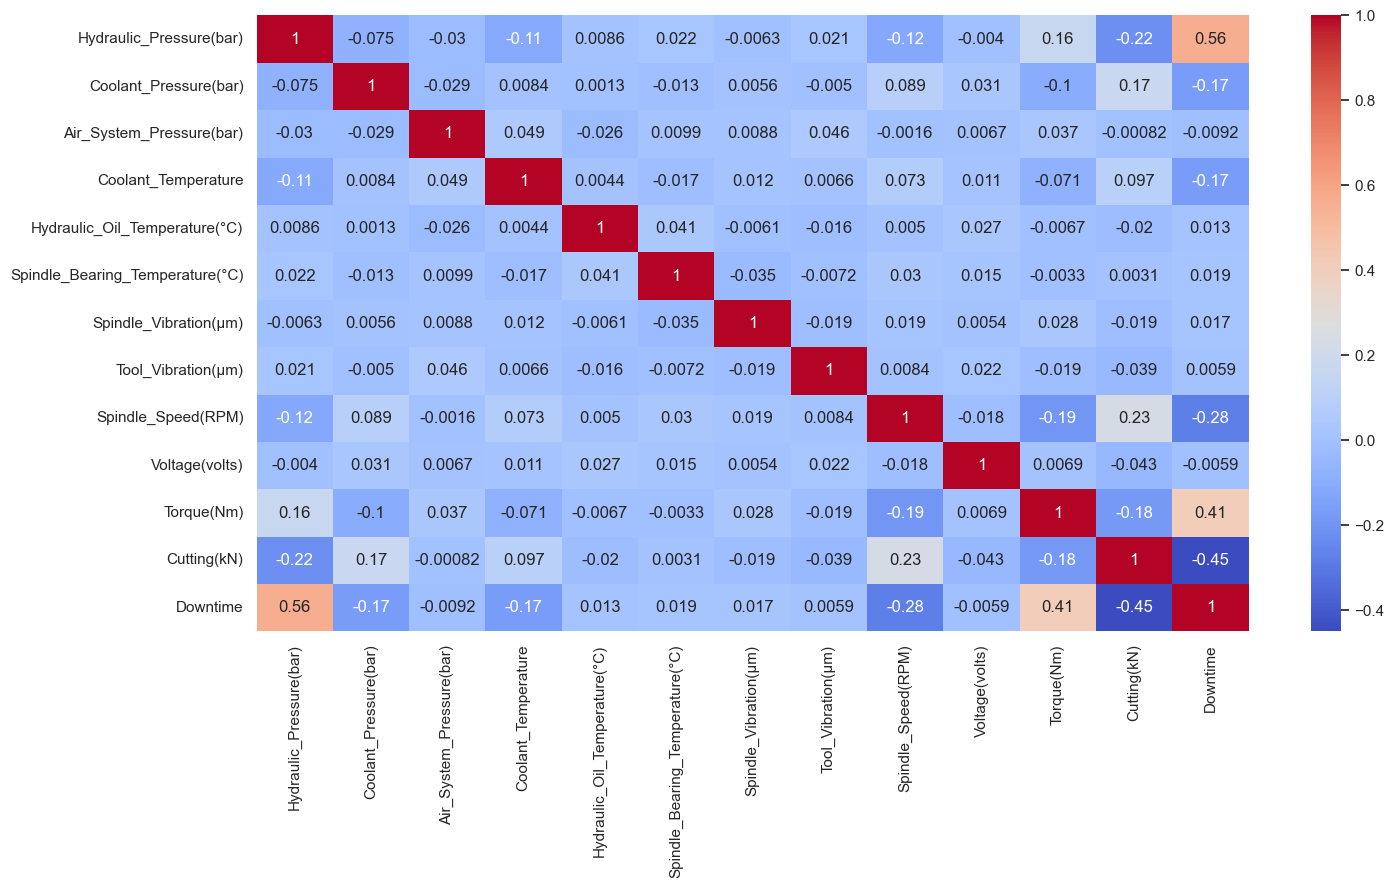

In [20]:
sns.set(rc = {'figure.figsize':(16, 8)})
sns.heatmap(data.corr(), annot = True, fmt='.2g', cmap= 'coolwarm')

In [21]:
data.duplicated().sum()

0

In [22]:
data1 = data
data1['Hydraulic_Pressure(bar)'] = data1['Hydraulic_Pressure(bar)'].fillna(data1['Hydraulic_Pressure(bar)'].mean())
data1['Coolant_Pressure(bar)'] = data1['Coolant_Pressure(bar)'].fillna(data1['Coolant_Pressure(bar)'].mean())
data1['Air_System_Pressure(bar)'] = data1['Air_System_Pressure(bar)'].fillna(data1['Air_System_Pressure(bar)'].mean())
data1['Coolant_Temperature'] = data1['Coolant_Temperature'].fillna(data1['Coolant_Temperature'].mean())
data1['Hydraulic_Oil_Temperature(°C)'] = data1['Hydraulic_Oil_Temperature(°C)'].fillna(data1['Hydraulic_Oil_Temperature(°C)'].mean())
data1['Spindle_Bearing_Temperature(°C)'] = data1['Spindle_Bearing_Temperature(°C)'].fillna(data1['Spindle_Bearing_Temperature(°C)'].mean())
data1['Spindle_Vibration(µm)'] = data1['Spindle_Vibration(µm)'].fillna(data1['Spindle_Vibration(µm)'].mean())
data1['Tool_Vibration(µm)'] = data1['Tool_Vibration(µm)'].fillna(data1['Tool_Vibration(µm)'].mean())
data1['Spindle_Speed(RPM)'] = data1['Spindle_Speed(RPM)'].fillna(data1['Spindle_Speed(RPM)'].mean())
data1['Voltage(volts)'] = data1['Voltage(volts)'].fillna(data1['Voltage(volts)'].mean())
data1['Torque(Nm)'] = data1['Torque(Nm)'].fillna(data1['Torque(Nm)'].mean())
data1['Cutting(kN)'] = data1['Cutting(kN)'].fillna(data1['Cutting(kN)'].mean())

In [23]:
data1.isnull().sum()

Hydraulic_Pressure(bar)            0
Coolant_Pressure(bar)              0
Air_System_Pressure(bar)           0
Coolant_Temperature                0
Hydraulic_Oil_Temperature(°C)      0
Spindle_Bearing_Temperature(°C)    0
Spindle_Vibration(µm)              0
Tool_Vibration(µm)                 0
Spindle_Speed(RPM)                 0
Voltage(volts)                     0
Torque(Nm)                         0
Cutting(kN)                        0
Downtime                           0
dtype: int64

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data1)

In [25]:
data_normalized

array([[0.41575965, 0.59943083, 0.41968035, ..., 0.43302046, 0.83568075,
        0.        ],
       [0.68016786, 0.41831219, 0.38936541, ..., 0.25566654, 0.41314554,
        0.        ],
       [0.41614927, 0.59087648, 0.54697204, ..., 0.4329114 , 0.82159624,
        0.        ],
       ...,
       [0.64760101, 0.44335522, 0.503887  , ..., 0.41004505, 0.46129162,
        1.        ],
       [0.7801348 , 0.44288223, 0.46011669, ..., 0.41049554, 0.46478873,
        1.        ],
       [0.54068266, 0.50898955, 0.70292643, ..., 0.43939688, 0.82159624,
        0.        ]])

In [26]:
def outlier_detect(data, column):
    plt.boxplot(data[column])
    Q1 = data[column].quantile(0.25)
    Q2 = data[column].quantile(0.75)
    IQR = Q2-Q1

    threshold = 1.5
    outliers = data[(data[column] < Q1 - threshold * IQR) | (data[column] > Q2 + threshold * IQR)]
    return outliers

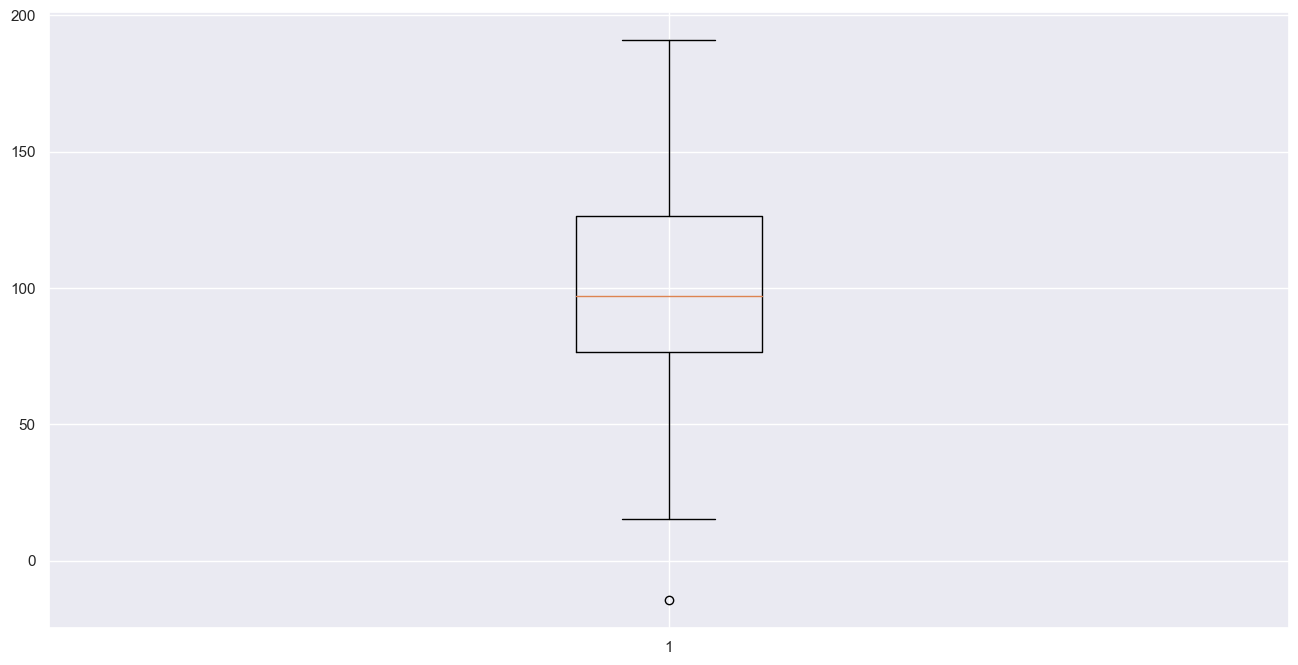

In [27]:
outliers = outlier_detect(data1, 'Hydraulic_Pressure(bar)')

{'whiskers': [<matplotlib.lines.Line2D at 0x2e817362c90>,
 'caps': [<matplotlib.lines.Line2D at 0x2e817363e10>,
 'boxes': [<matplotlib.lines.Line2D at 0x2e8173622d0>],
 'medians': [<matplotlib.lines.Line2D at 0x2e817370f50>],
 'fliers': [<matplotlib.lines.Line2D at 0x2e814e43f10>],
 'means': []}

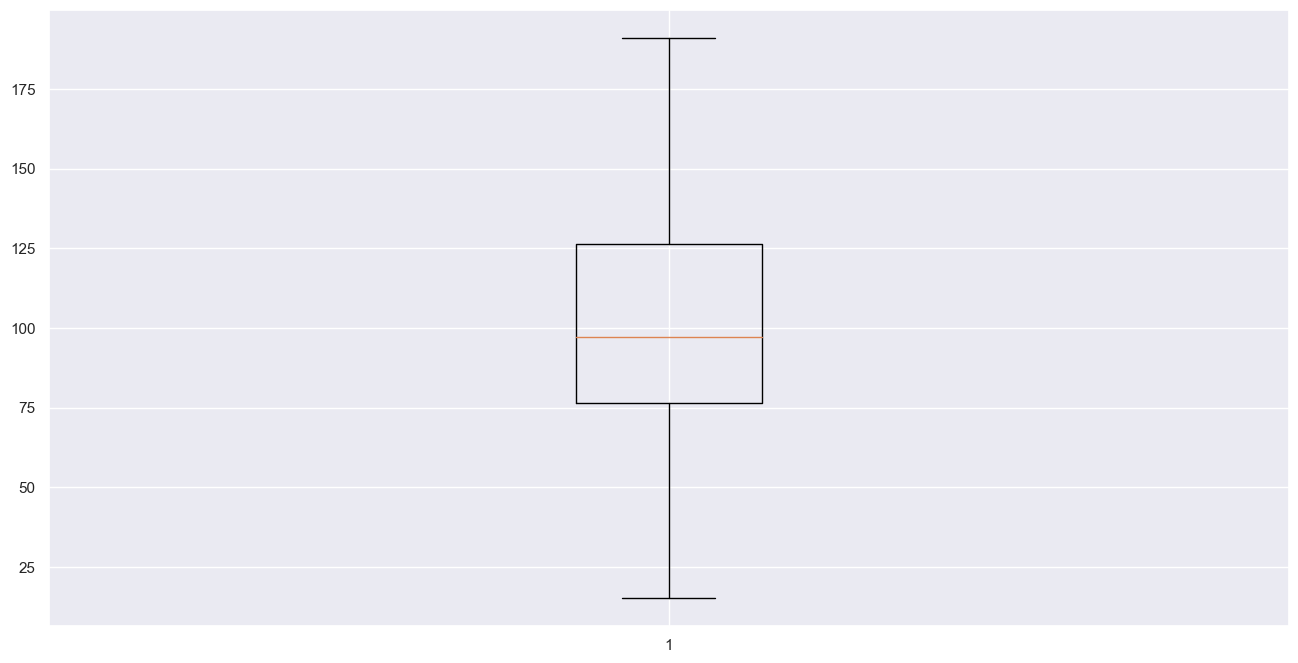

In [28]:
data1 = data1.drop(outliers.index)
plt.boxplot(data1['Hydraulic_Pressure(bar)'])

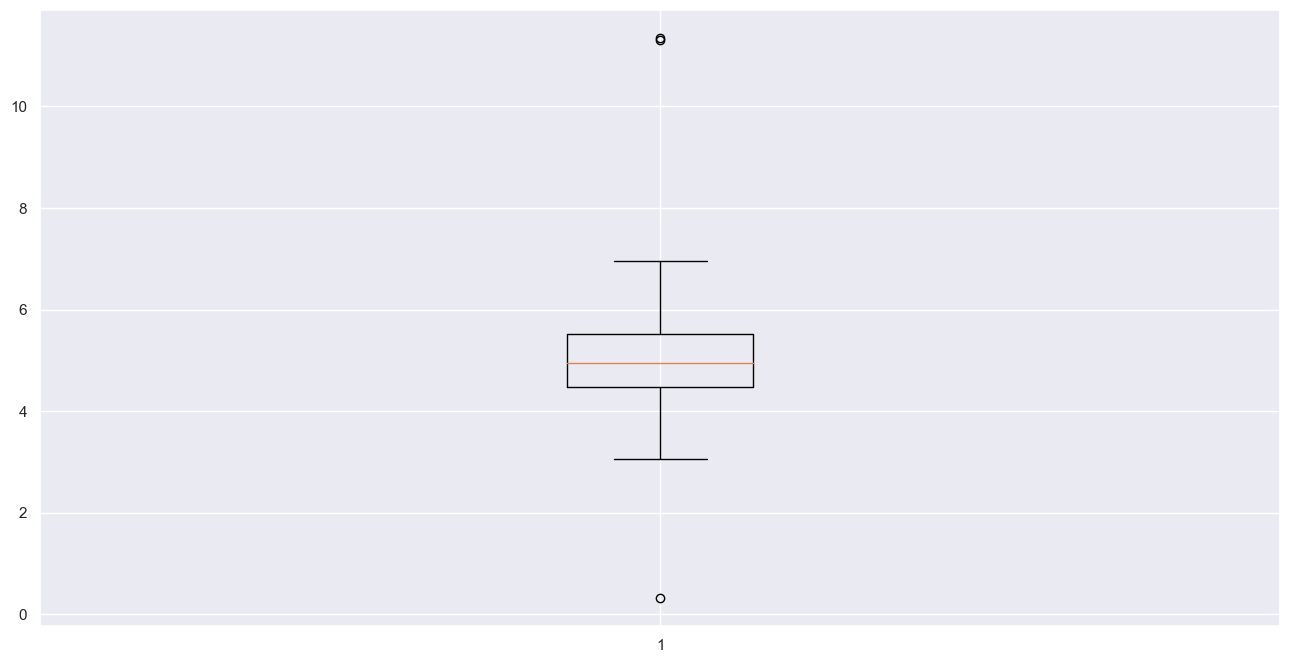

In [29]:
outliers = outlier_detect(data1, 'Coolant_Pressure(bar)')

{'whiskers': [<matplotlib.lines.Line2D at 0x2e8173ce490>,
 'caps': [<matplotlib.lines.Line2D at 0x2e8173cf750>,
 'boxes': [<matplotlib.lines.Line2D at 0x2e8173cdb50>],
 'medians': [<matplotlib.lines.Line2D at 0x2e8173e0710>],
 'fliers': [<matplotlib.lines.Line2D at 0x2e817370e90>],
 'means': []}

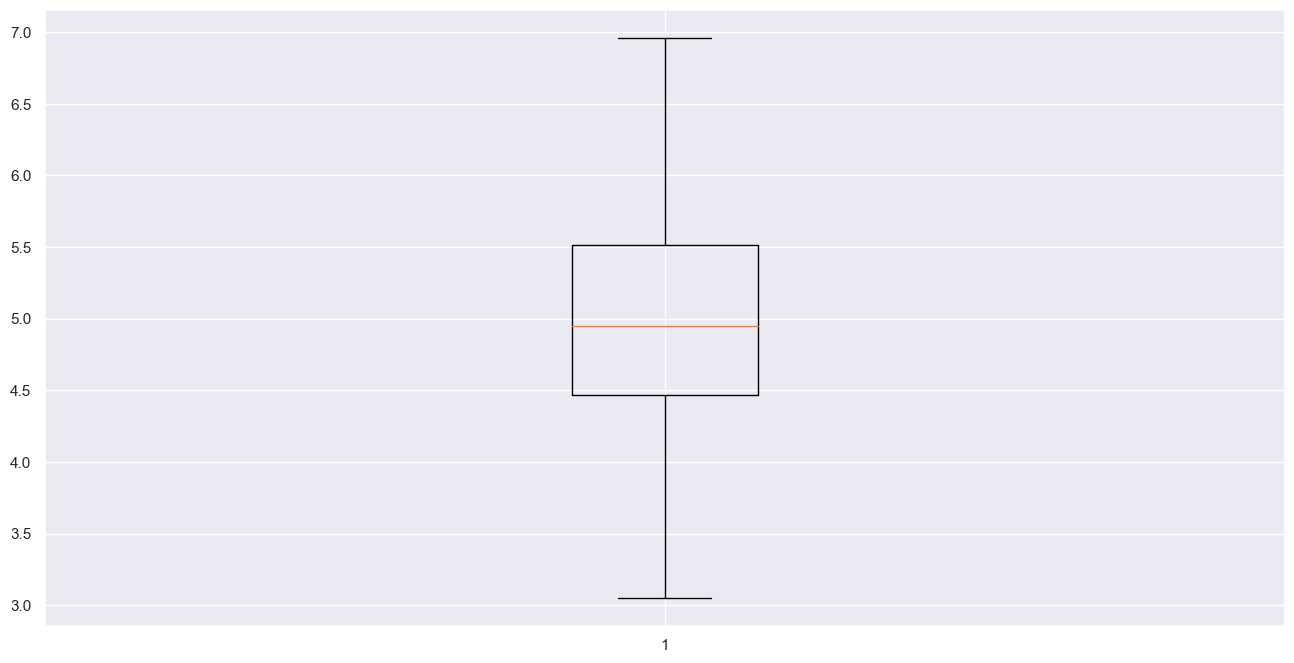

In [30]:
data1 = data1.drop(outliers.index)
plt.boxplot(data1['Coolant_Pressure(bar)'])

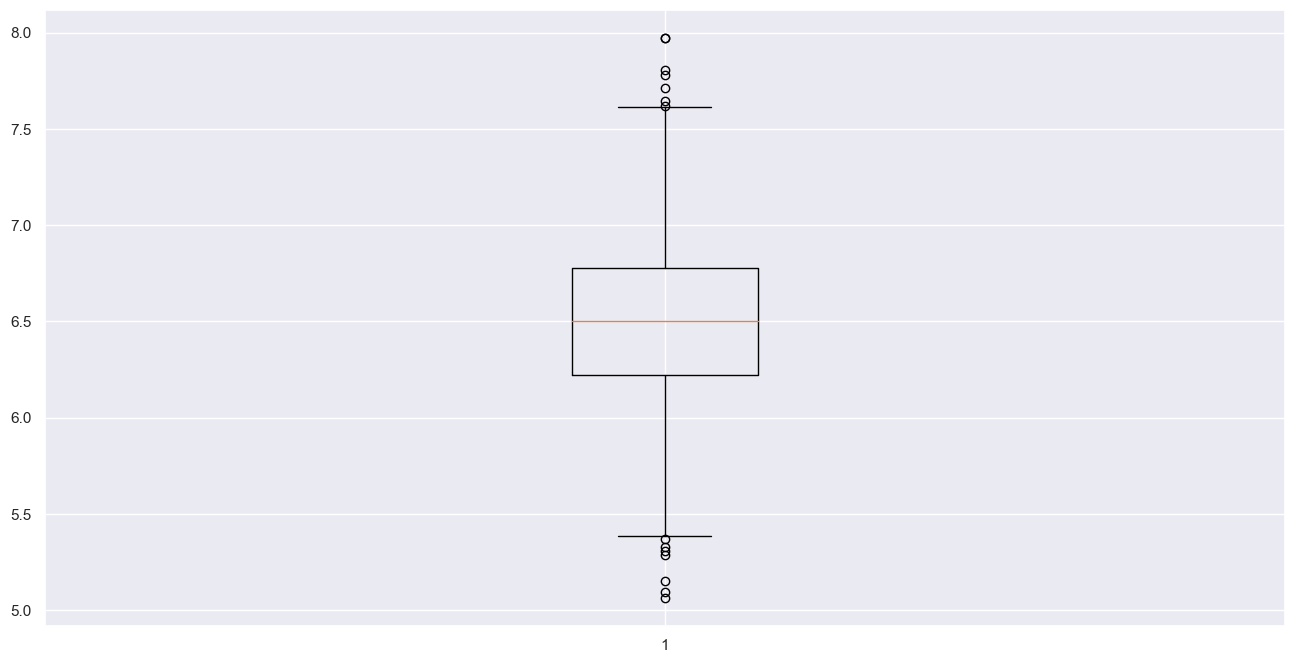

In [31]:
outliers = outlier_detect(data1, 'Air_System_Pressure(bar)')

{'whiskers': [<matplotlib.lines.Line2D at 0x2e817f253d0>,
 'caps': [<matplotlib.lines.Line2D at 0x2e817f26910>,
 'boxes': [<matplotlib.lines.Line2D at 0x2e8176a4390>],
 'medians': [<matplotlib.lines.Line2D at 0x2e817f27a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x2e817f30510>],
 'means': []}

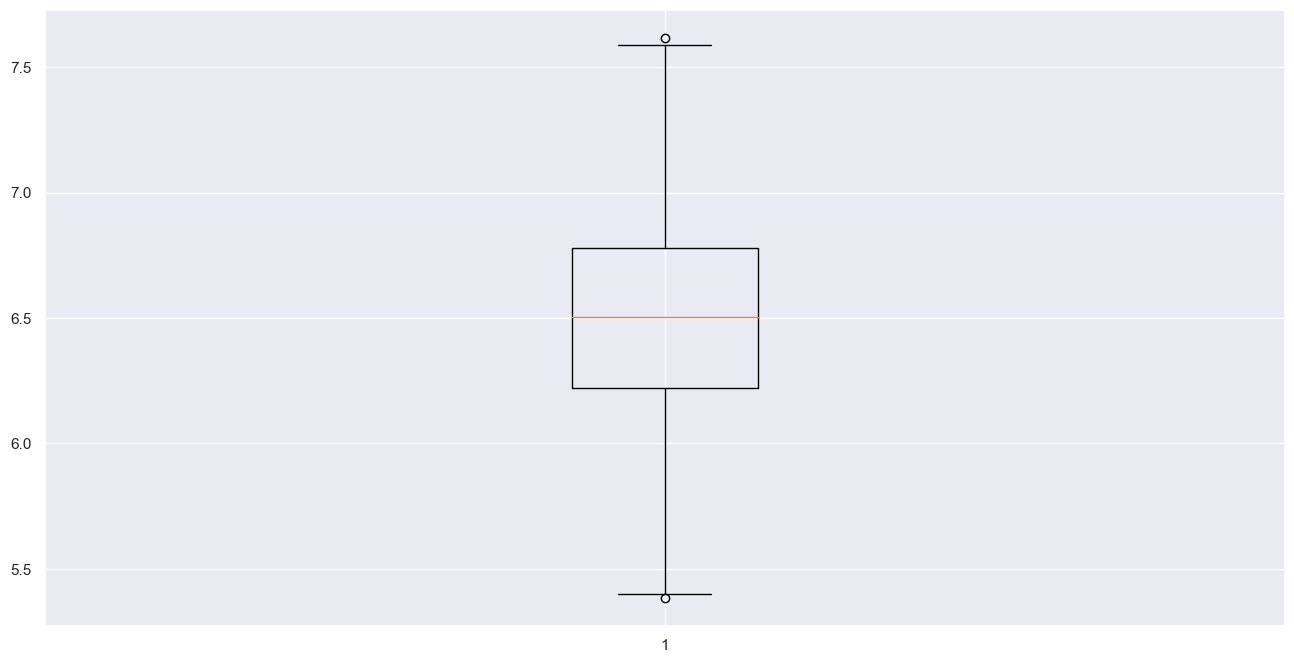

In [32]:
data1 = data1.drop(outliers.index)
plt.boxplot(data1['Air_System_Pressure(bar)'])

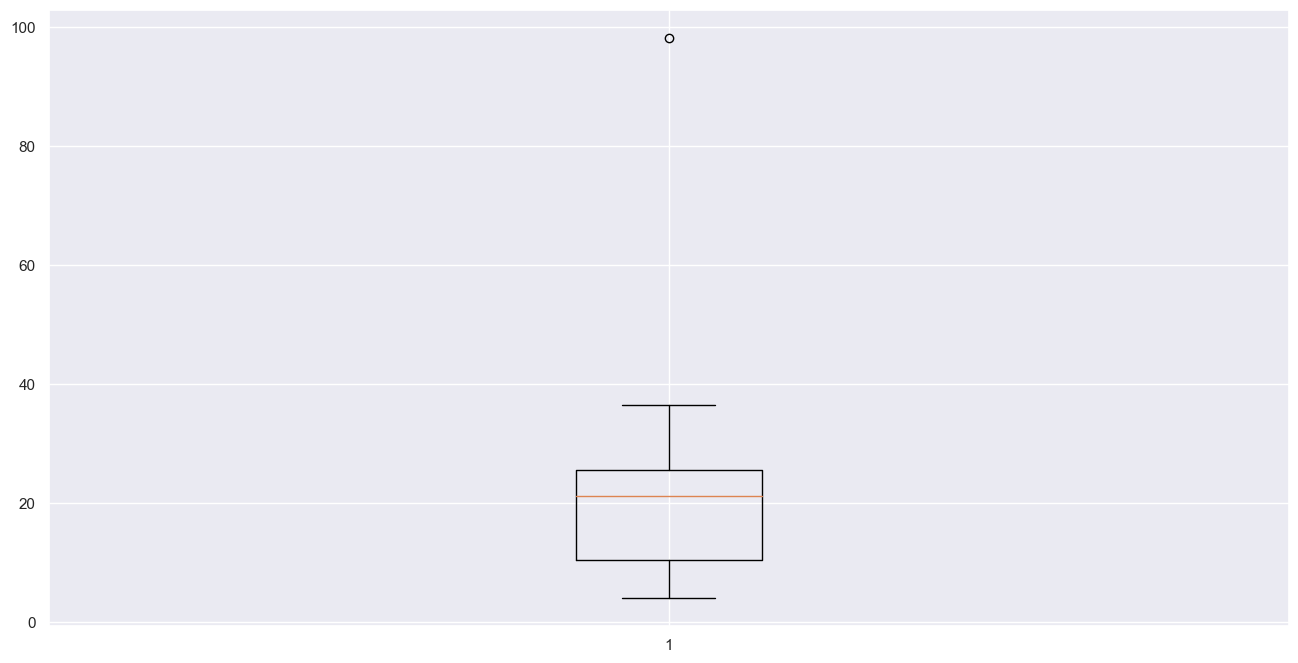

In [33]:
outliers = outlier_detect(data1, 'Coolant_Temperature')

{'whiskers': [<matplotlib.lines.Line2D at 0x2e817fdff90>,
 'caps': [<matplotlib.lines.Line2D at 0x2e817fedb10>,
 'boxes': [<matplotlib.lines.Line2D at 0x2e8176bfa50>],
 'medians': [<matplotlib.lines.Line2D at 0x2e817fef0d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2e817fed650>],
 'means': []}

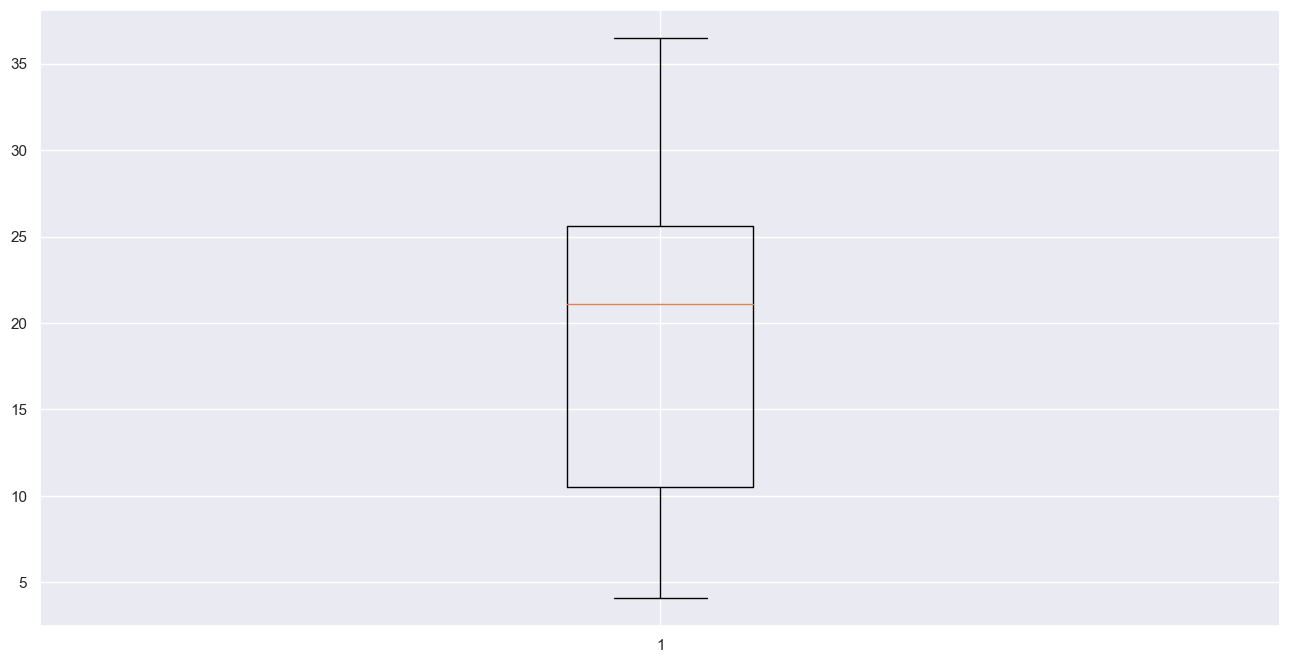

In [34]:
data1 = data1.drop(outliers.index)
plt.boxplot(data1['Coolant_Temperature'])

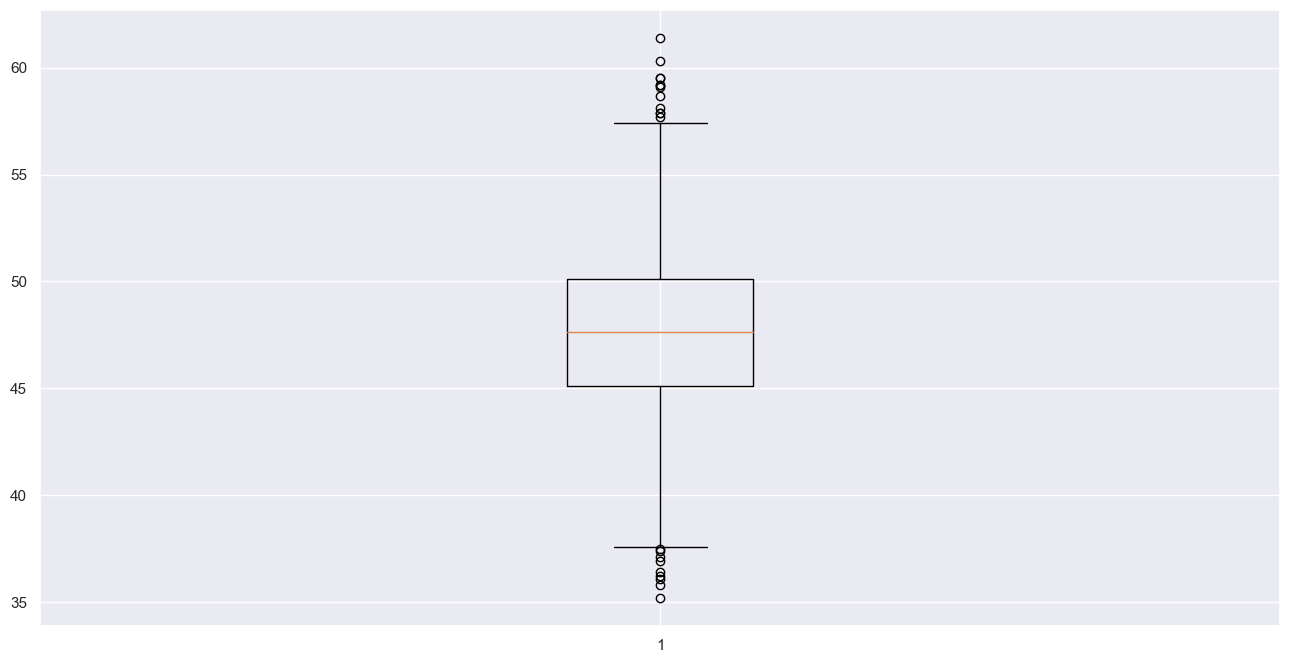

In [35]:
outliers = outlier_detect(data1, 'Hydraulic_Oil_Temperature(°C)')

{'whiskers': [<matplotlib.lines.Line2D at 0x2e818493210>,
 'caps': [<matplotlib.lines.Line2D at 0x2e81849c910>,
 'boxes': [<matplotlib.lines.Line2D at 0x2e818492550>],
 'medians': [<matplotlib.lines.Line2D at 0x2e81849df50>],
 'fliers': [<matplotlib.lines.Line2D at 0x2e818493d10>],
 'means': []}

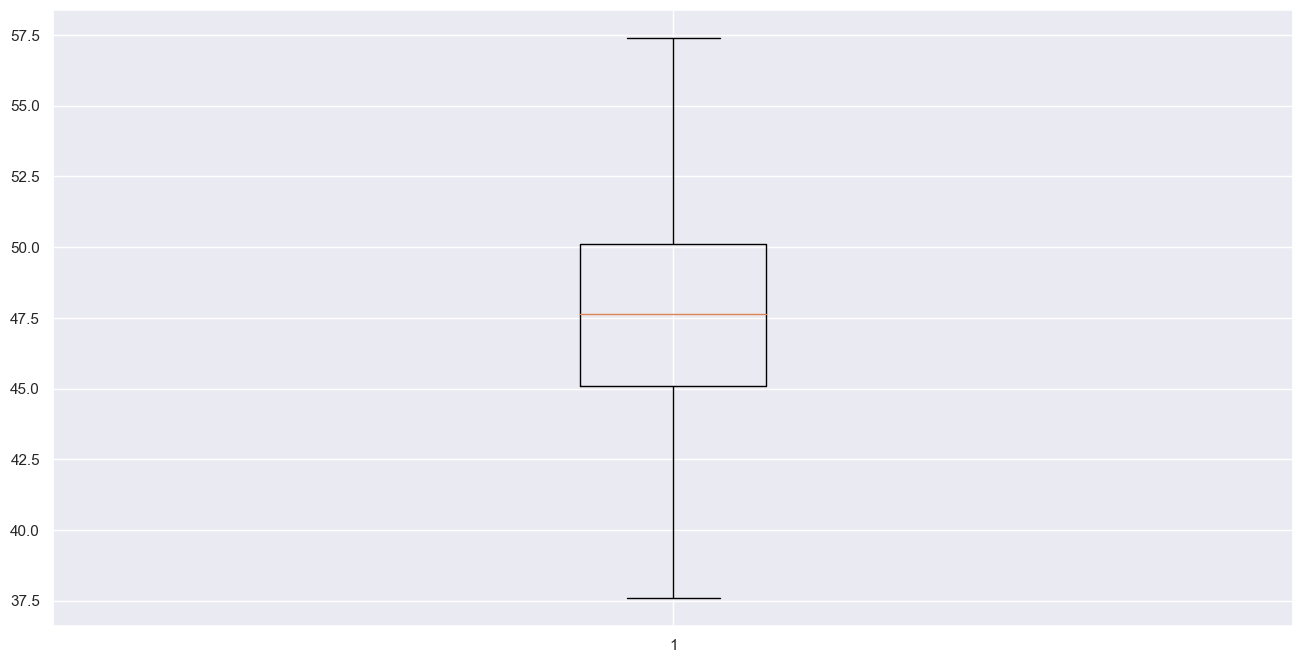

In [36]:
data1 = data1.drop(outliers.index)
plt.boxplot(data1['Hydraulic_Oil_Temperature(°C)'])

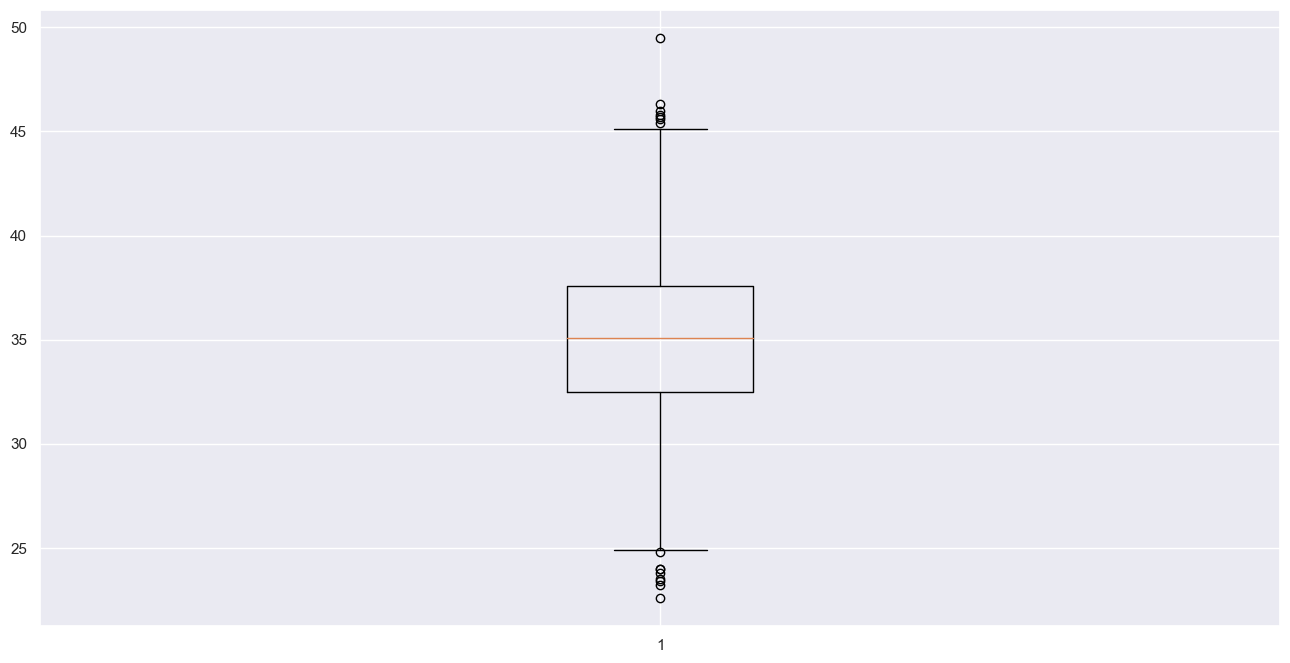

In [37]:
outliers = outlier_detect(data1, 'Spindle_Bearing_Temperature(°C)')

{'whiskers': [<matplotlib.lines.Line2D at 0x2e818fcee50>,
 'caps': [<matplotlib.lines.Line2D at 0x2e818fd4dd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2e818fceb10>],
 'medians': [<matplotlib.lines.Line2D at 0x2e818fd57d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2e818fb5d50>],
 'means': []}

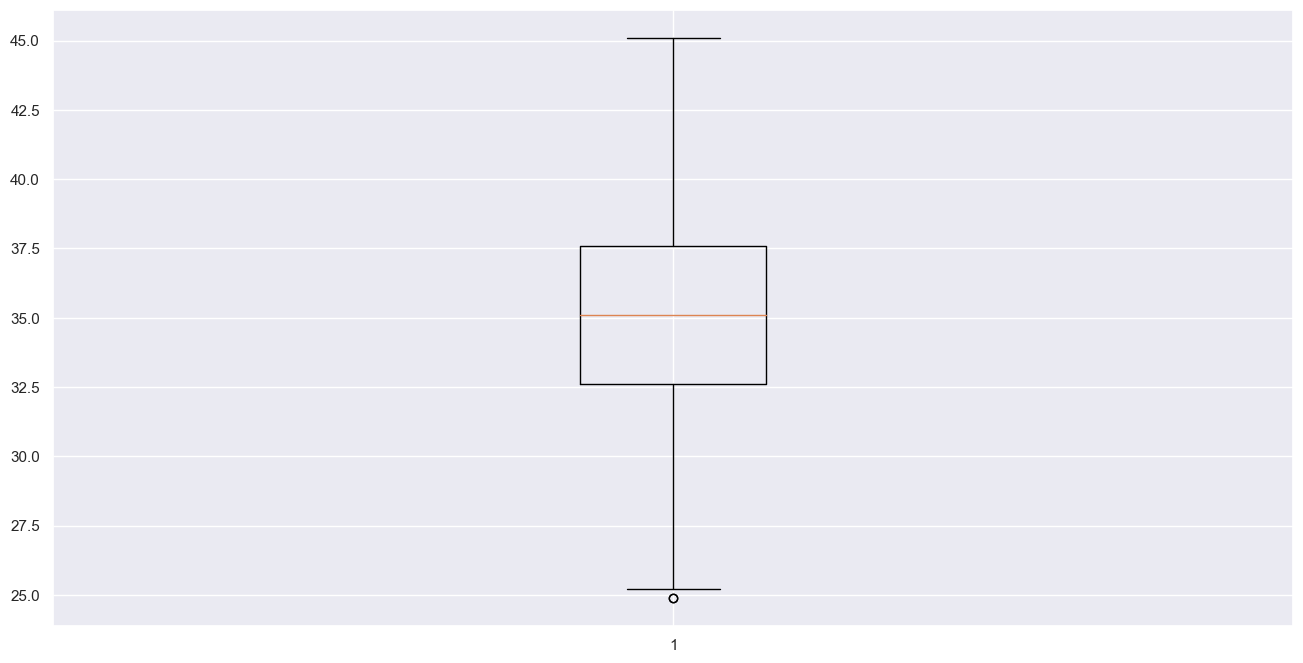

In [38]:
data1 = data1.drop(outliers.index)
plt.boxplot(data1['Spindle_Bearing_Temperature(°C)'])

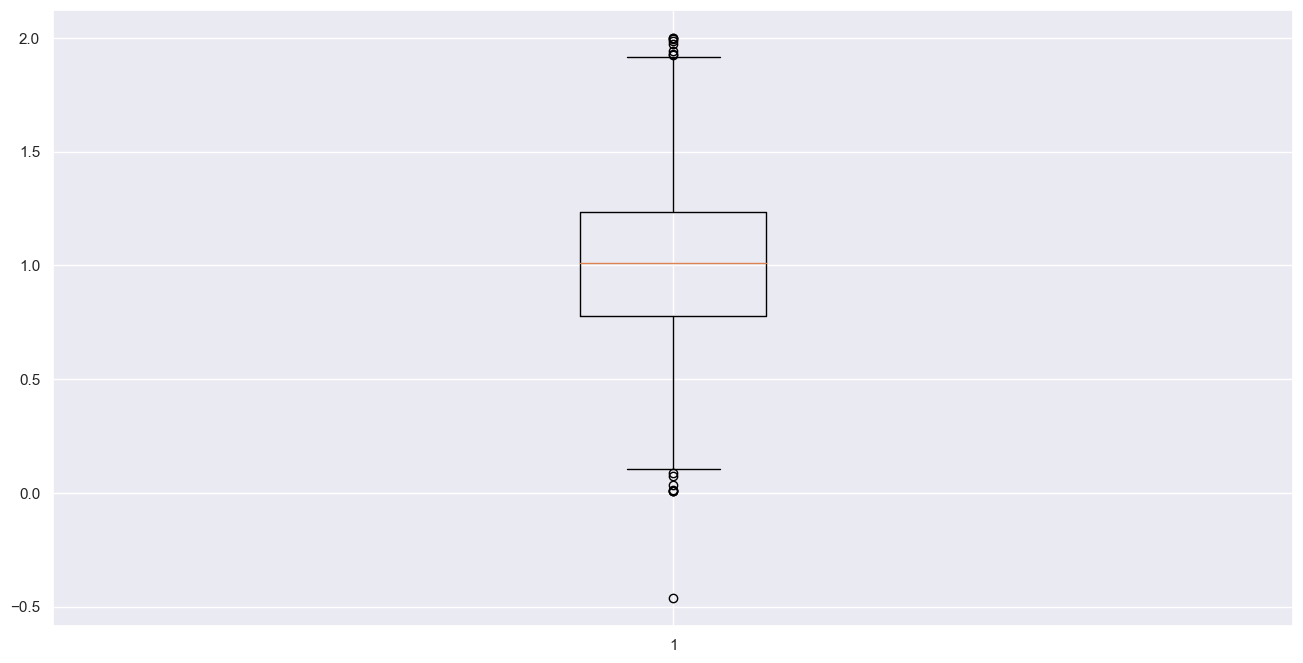

In [39]:
outliers = outlier_detect(data1, 'Spindle_Vibration(µm)')

{'whiskers': [<matplotlib.lines.Line2D at 0x2e81844c710>,
 'caps': [<matplotlib.lines.Line2D at 0x2e819035410>,
 'boxes': [<matplotlib.lines.Line2D at 0x2e819086150>],
 'medians': [<matplotlib.lines.Line2D at 0x2e819037a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x2e819037090>],
 'means': []}

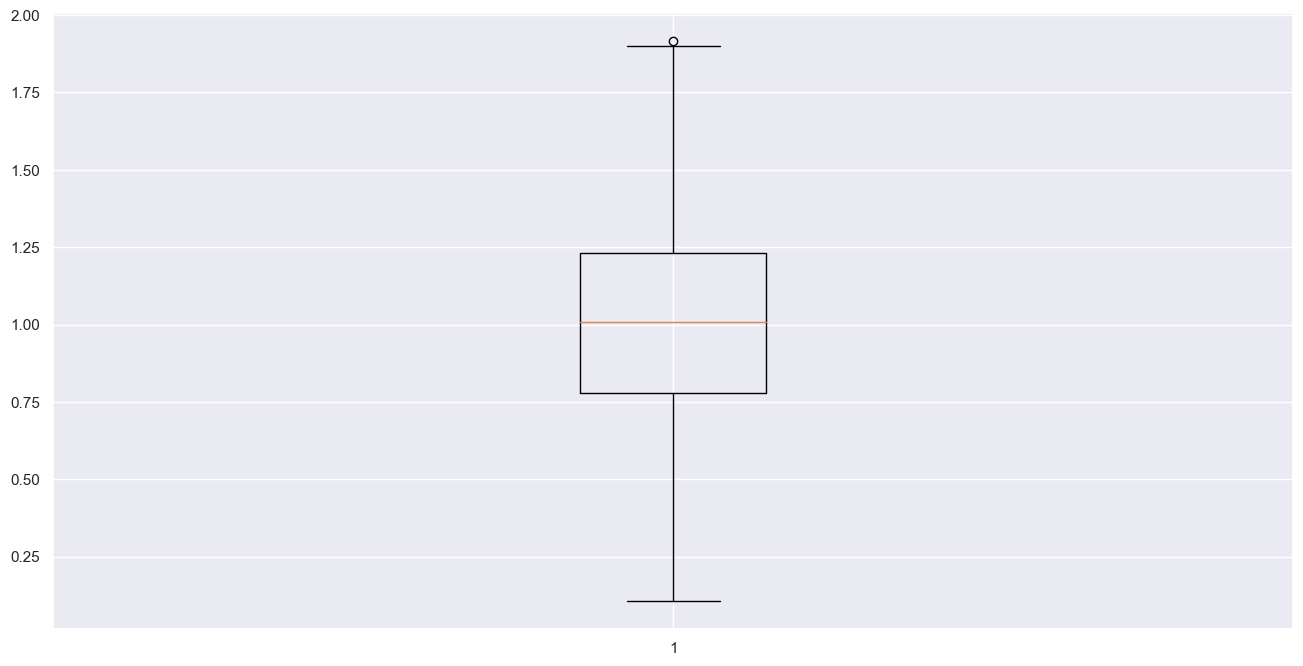

In [40]:
data1 = data1.drop(outliers.index)
plt.boxplot(data1['Spindle_Vibration(µm)'])

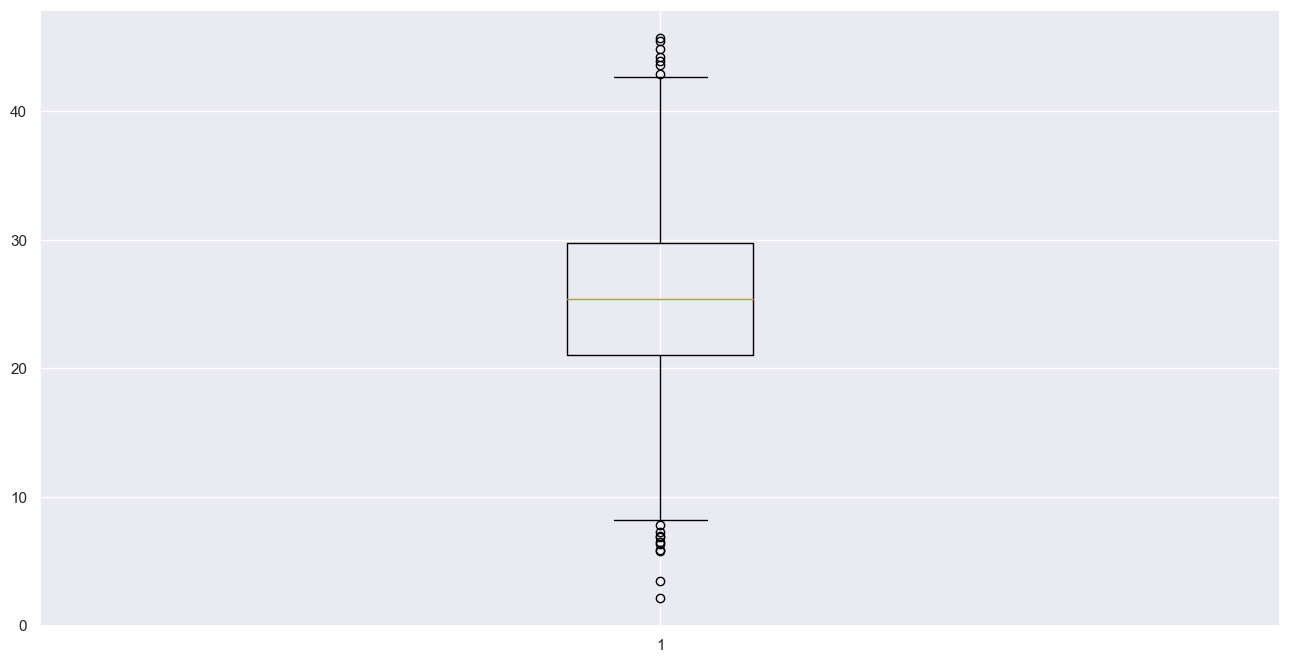

In [41]:
outliers = outlier_detect(data1, 'Tool_Vibration(µm)')

{'whiskers': [<matplotlib.lines.Line2D at 0x2e819b841d0>,
 'caps': [<matplotlib.lines.Line2D at 0x2e819b857d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2e819b7b510>],
 'medians': [<matplotlib.lines.Line2D at 0x2e819b86c10>],
 'fliers': [<matplotlib.lines.Line2D at 0x2e817624150>],
 'means': []}

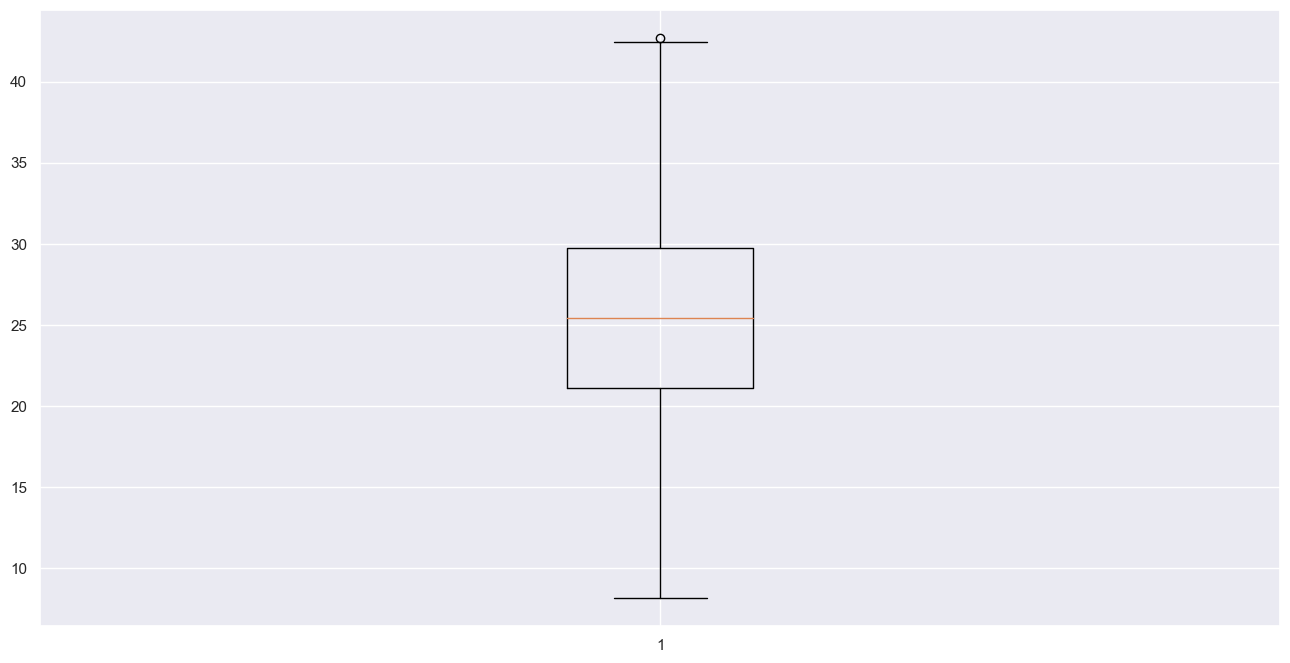

In [42]:
data1 = data1.drop(outliers.index)
plt.boxplot(data1['Tool_Vibration(µm)'])

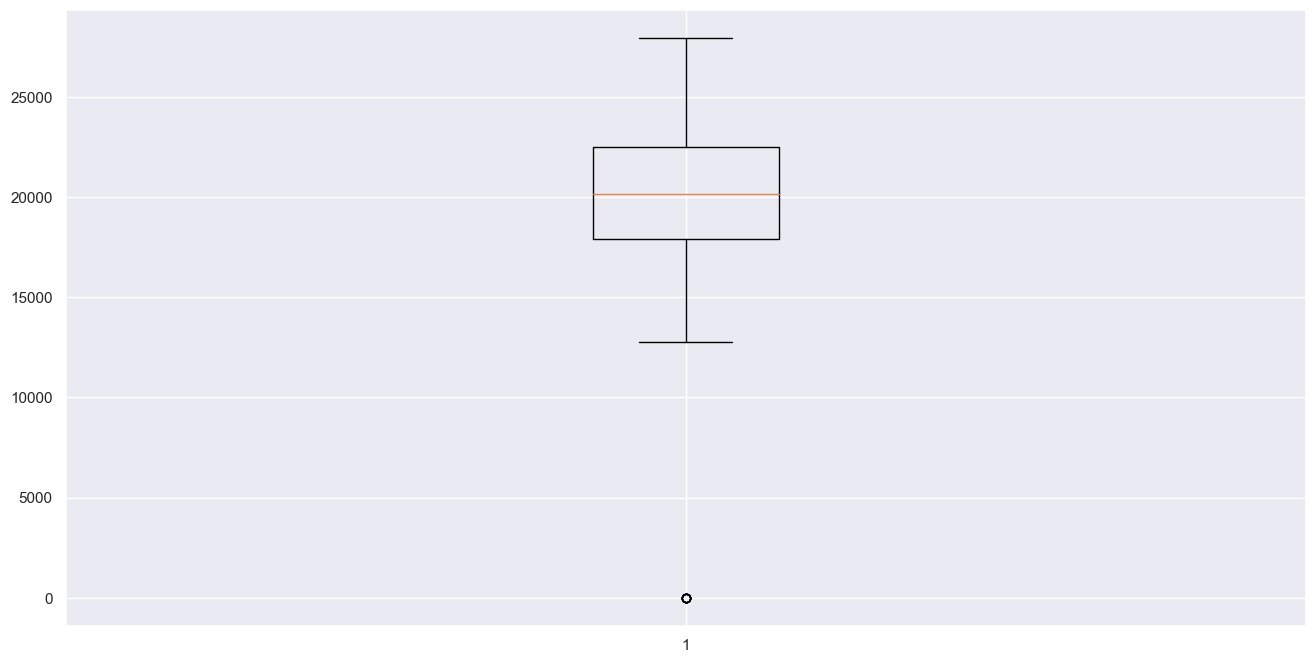

In [43]:
outliers = outlier_detect(data1, 'Spindle_Speed(RPM)')

{'whiskers': [<matplotlib.lines.Line2D at 0x2e819bfc150>,
 'caps': [<matplotlib.lines.Line2D at 0x2e819bfd5d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2e819beb750>],
 'medians': [<matplotlib.lines.Line2D at 0x2e819bfe790>],
 'fliers': [<matplotlib.lines.Line2D at 0x2e819bcd0d0>],
 'means': []}

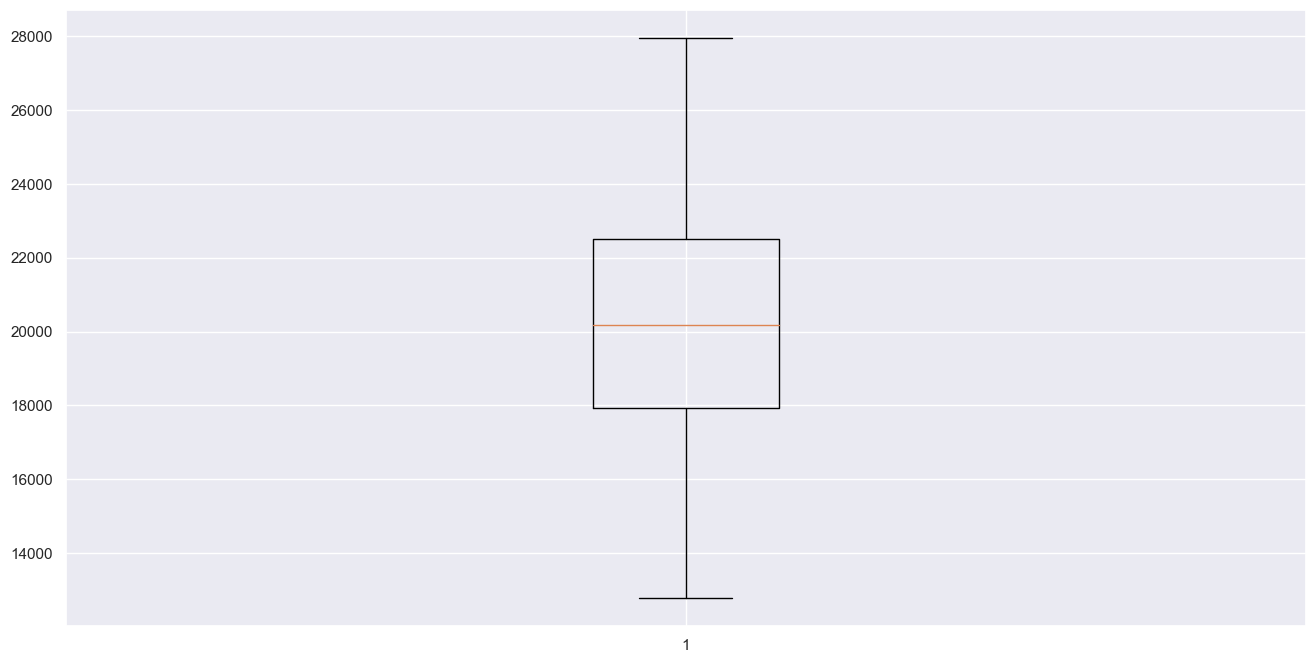

In [44]:
data1 = data1.drop(outliers.index)
plt.boxplot(data1['Spindle_Speed(RPM)'])

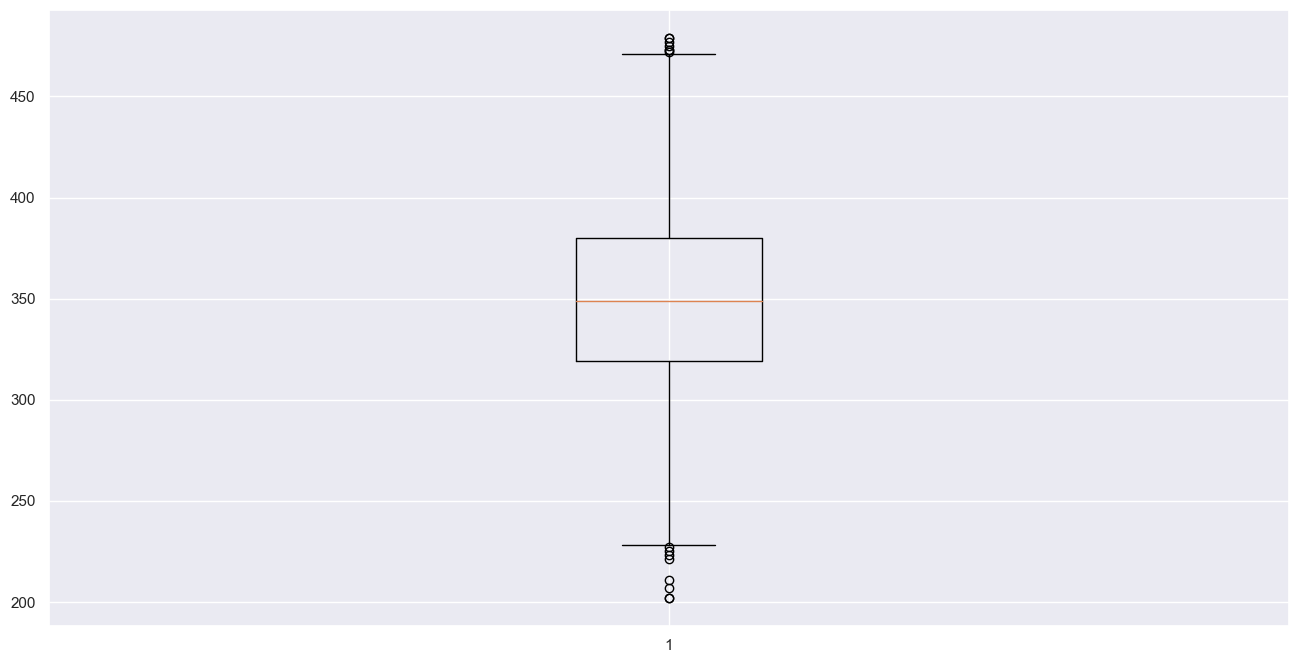

In [45]:
outliers = outlier_detect(data1, 'Voltage(volts)')

{'whiskers': [<matplotlib.lines.Line2D at 0x2e81ac03650>,
 'caps': [<matplotlib.lines.Line2D at 0x2e81ac14890>,
 'boxes': [<matplotlib.lines.Line2D at 0x2e81ac02c10>],
 'medians': [<matplotlib.lines.Line2D at 0x2e81ac15a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x2e81903c650>],
 'means': []}

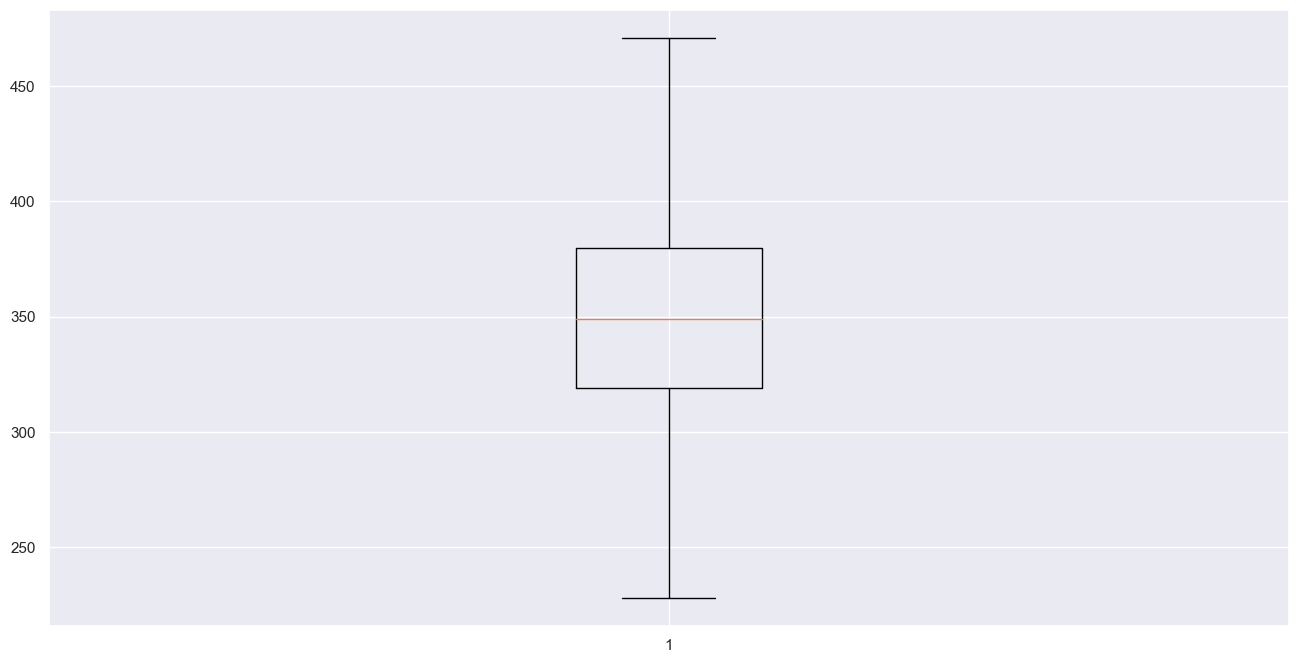

In [46]:
data1 = data1.drop(outliers.index)
plt.boxplot(data1['Voltage(volts)'])

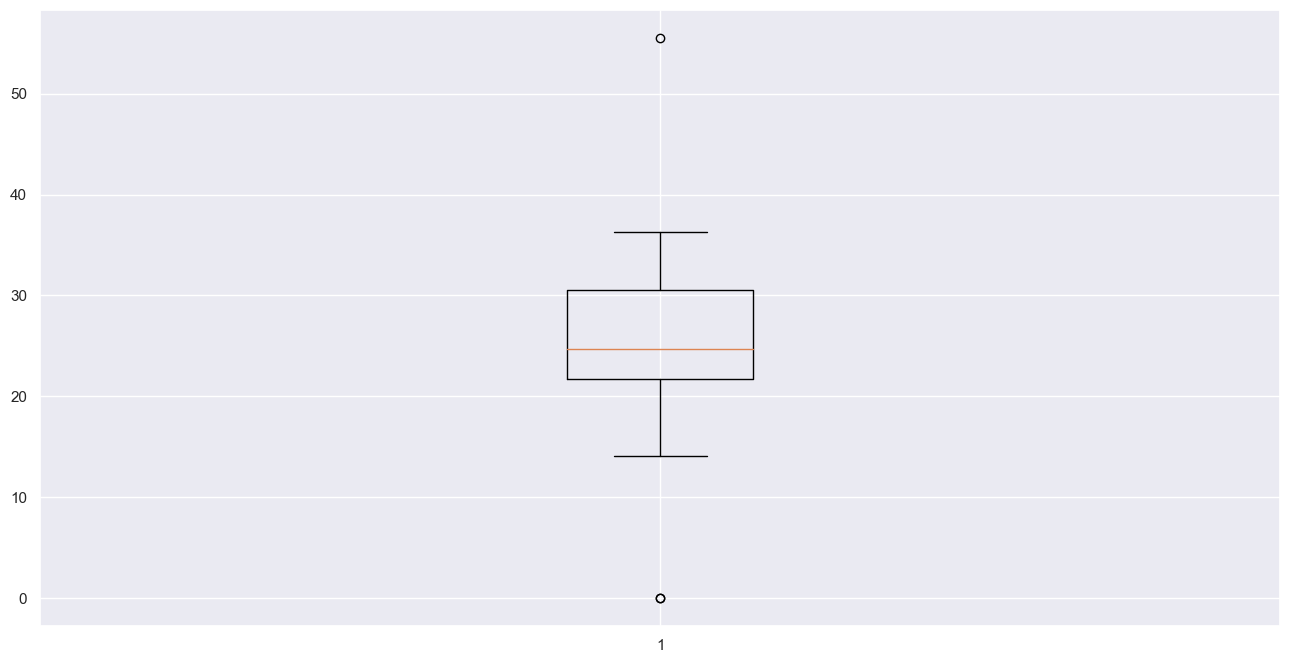

In [47]:
outliers = outlier_detect(data1, 'Torque(Nm)')

{'whiskers': [<matplotlib.lines.Line2D at 0x2e819b55f90>,
 'caps': [<matplotlib.lines.Line2D at 0x2e81acbf6d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2e81acbd450>],
 'medians': [<matplotlib.lines.Line2D at 0x2e81acccb90>],
 'fliers': [<matplotlib.lines.Line2D at 0x2e81accd5d0>],
 'means': []}

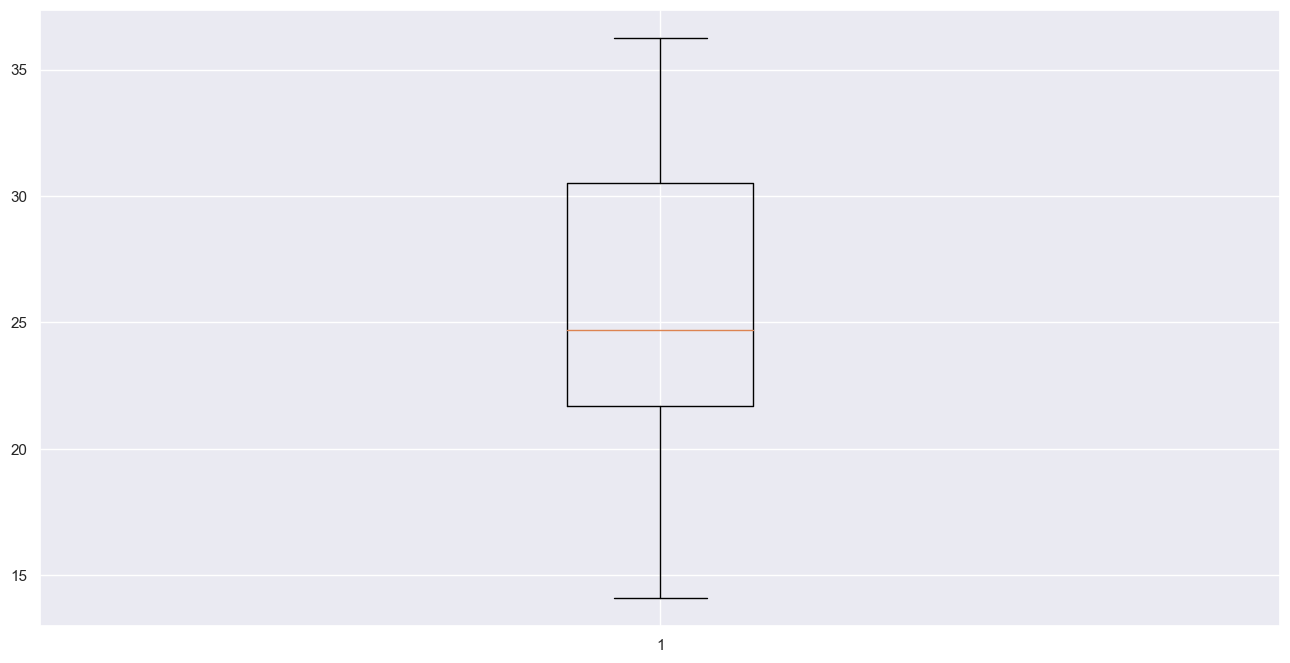

In [48]:
data1 = data1.drop(outliers.index)
plt.boxplot(data1['Torque(Nm)'])

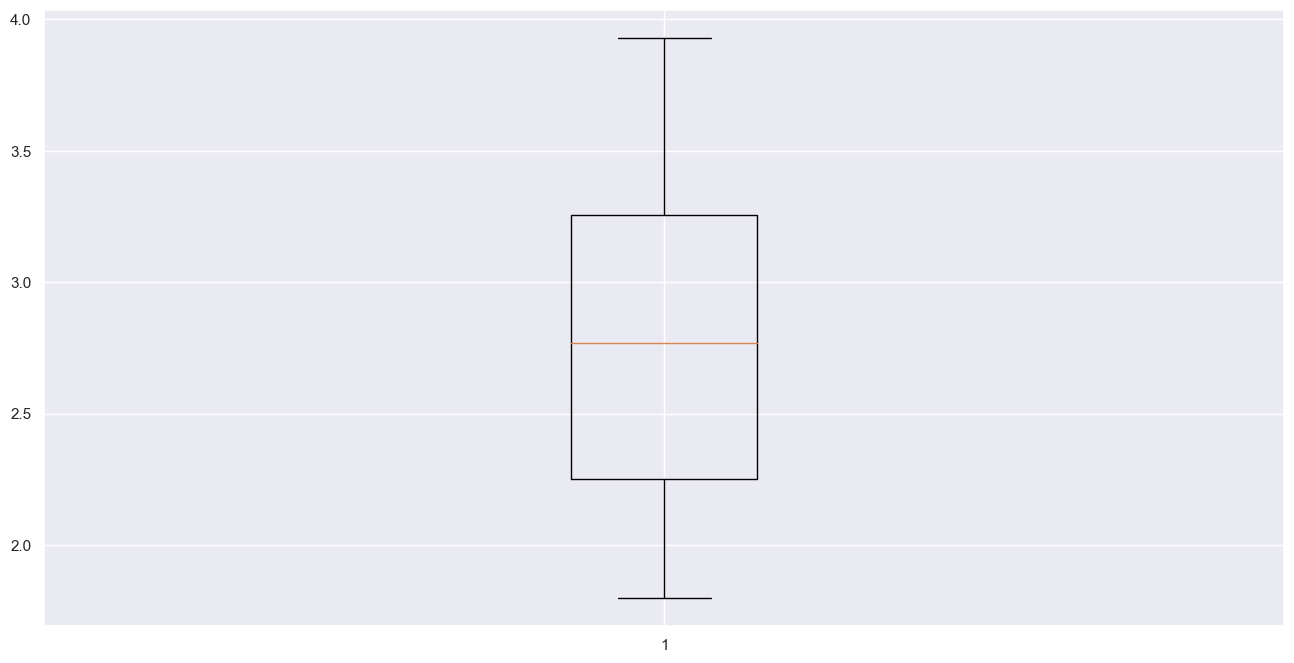

In [49]:
outliers = outlier_detect(data1, 'Cutting(kN)')

{'whiskers': [<matplotlib.lines.Line2D at 0x2e818fb5010>,
 'caps': [<matplotlib.lines.Line2D at 0x2e81a3f7690>,
 'boxes': [<matplotlib.lines.Line2D at 0x2e81a3f4390>],
 'medians': [<matplotlib.lines.Line2D at 0x2e81ac4c6d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2e81ac4e4d0>],
 'means': []}

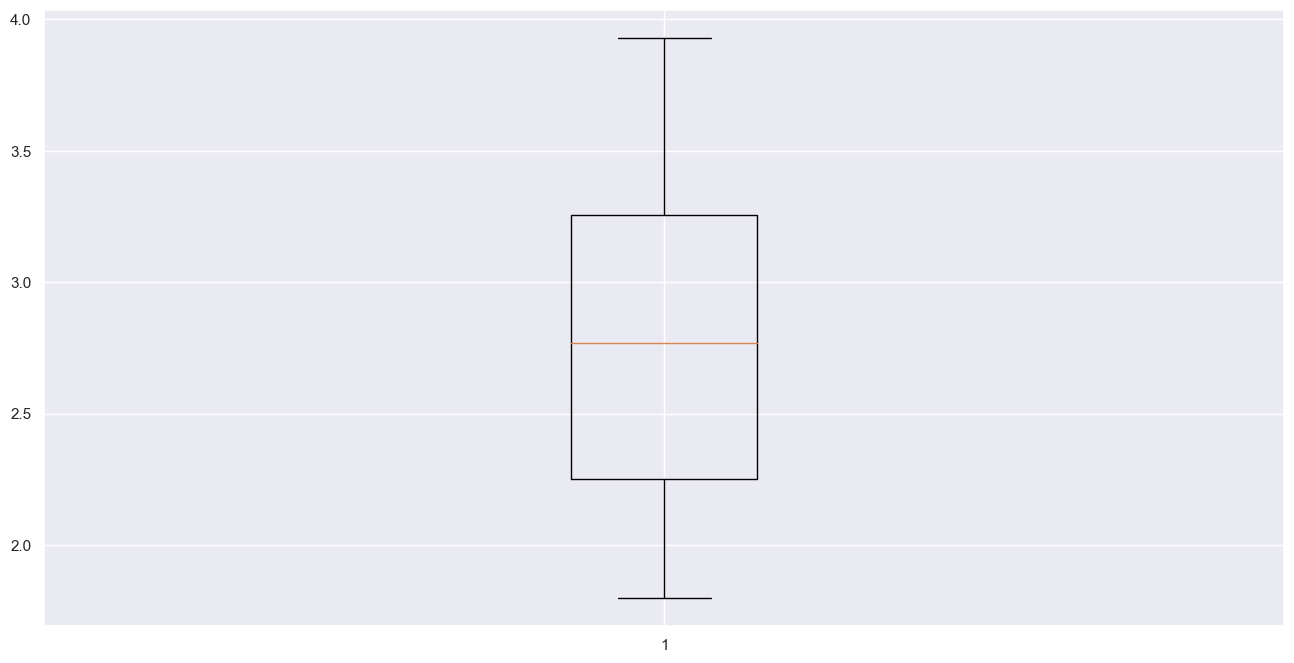

In [50]:
data1 = data1.drop(outliers.index)
plt.boxplot(data1['Cutting(kN)'])

(array([  1.,  10., 362., 474., 504., 286., 418., 257.,  69.,   6.]),
 array([ 15.32576081,  32.89318473,  50.46060865,  68.02803257,
         85.59545649, 103.1628804 , 120.73030432, 138.29772824,
        155.86515216, 173.43257608, 191.        ]),
 <BarContainer object of 10 artists>)

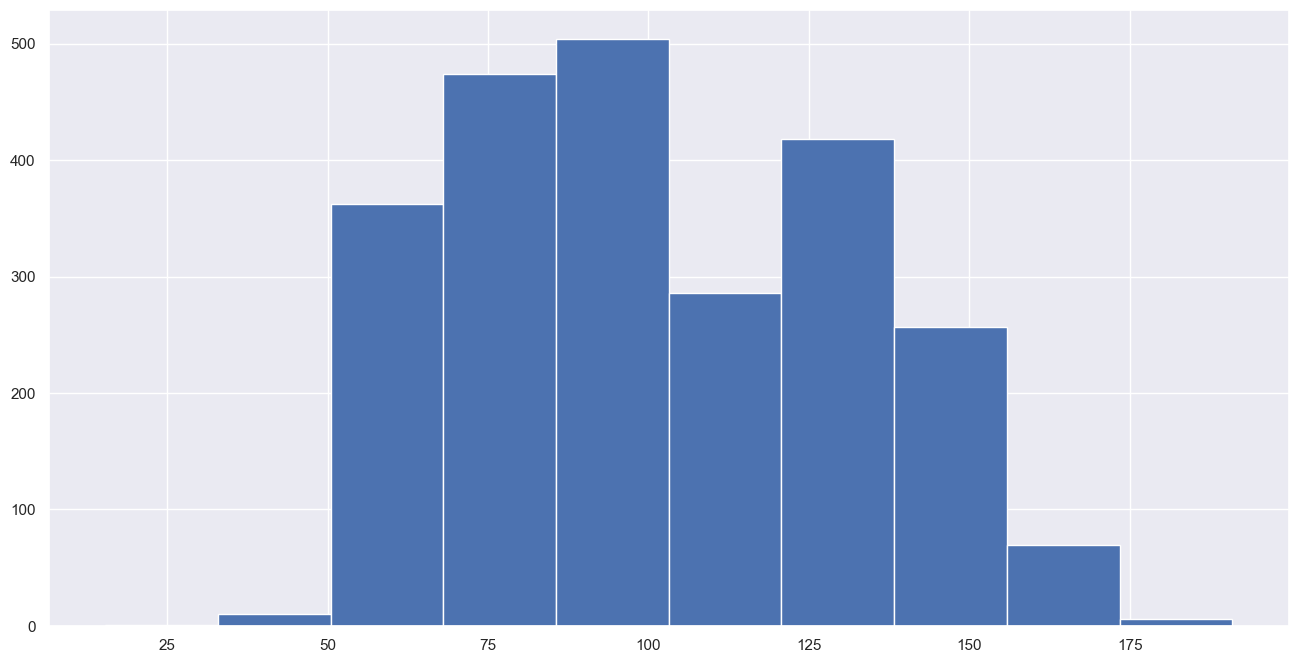

In [51]:
plt.hist(data1['Hydraulic_Pressure(bar)'], bins=10)

(array([250.,  50., 158., 308., 511., 420., 316., 122.,  70., 182.]),
 array([3.05314884, 3.44389754, 3.83464625, 4.22539496, 4.61614367,
        5.00689237, 5.39764108, 5.78838979, 6.17913849, 6.5698872 ,
        6.96063591]),
 <BarContainer object of 10 artists>)

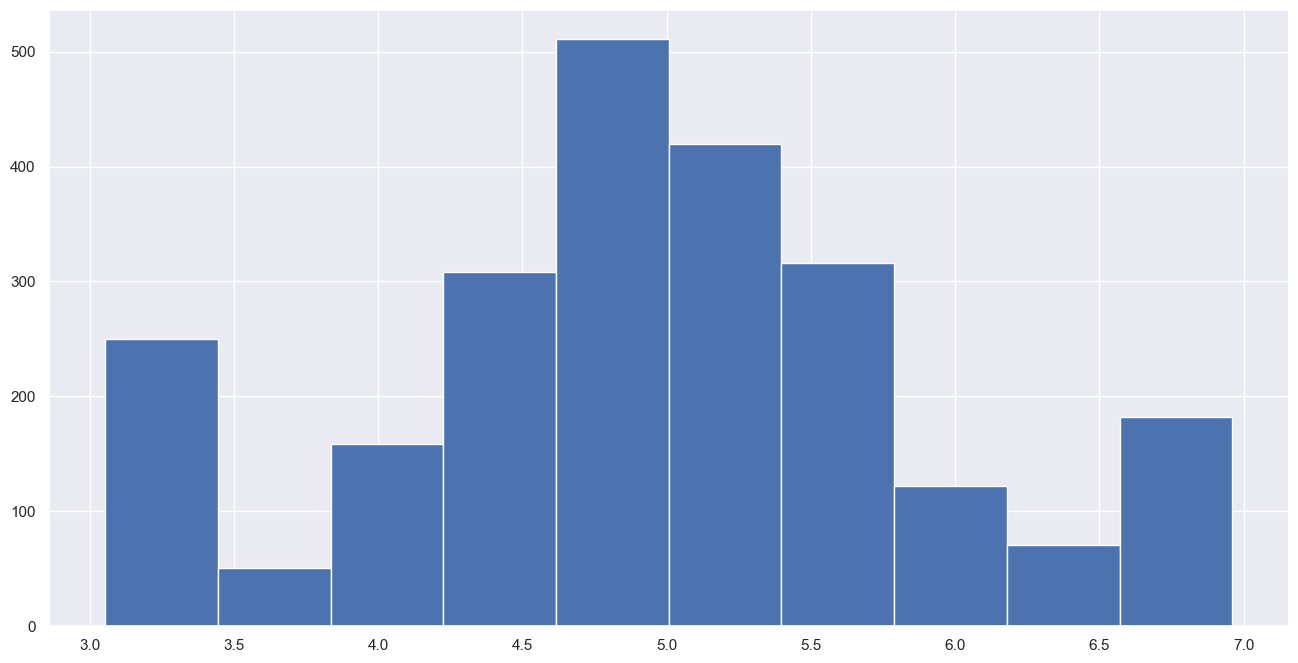

In [52]:
plt.hist(data1['Coolant_Pressure(bar)'], bins=10)

(array([ 27.,  88., 198., 390., 484., 488., 399., 217.,  71.,  25.]),
 array([5.38444931, 5.60768093, 5.83091256, 6.05414419, 6.27737582,
        6.50060744, 6.72383907, 6.9470707 , 7.17030233, 7.39353396,
        7.61676558]),
 <BarContainer object of 10 artists>)

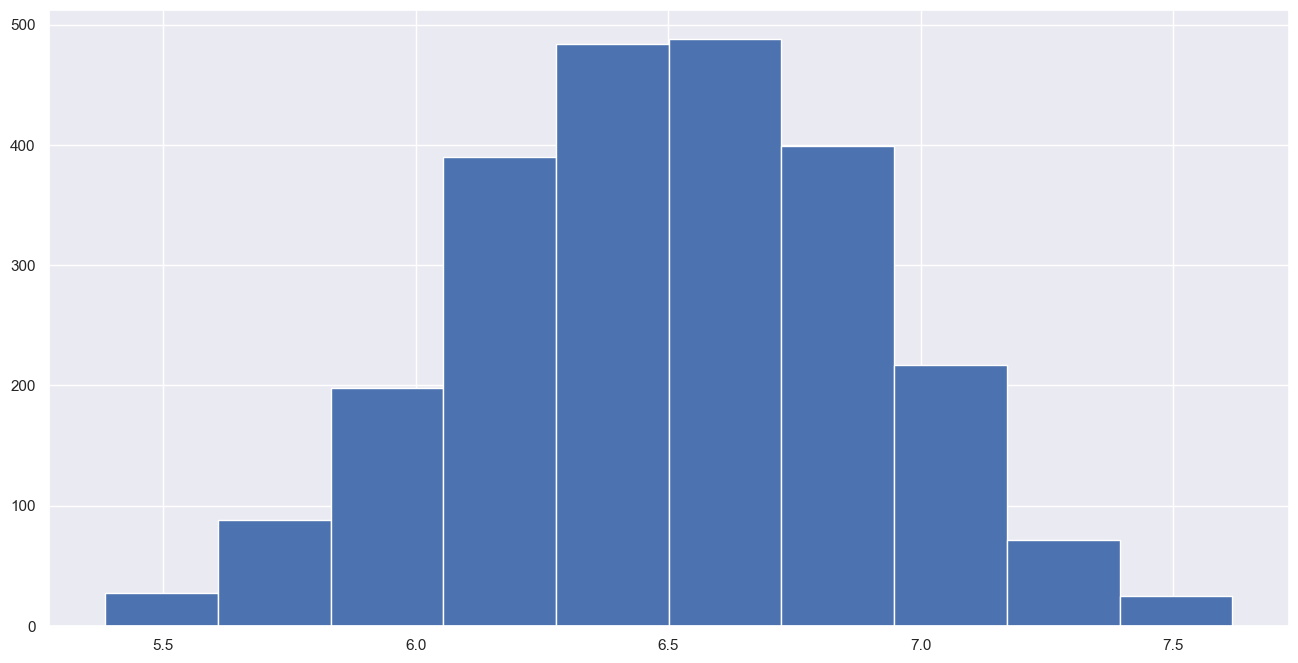

In [53]:
plt.hist(data1['Air_System_Pressure(bar)'], bins=10)

(array([291., 308., 290.,  95., 115., 366., 537., 269., 100.,  16.]),
 array([ 4.1 ,  7.34, 10.58, 13.82, 17.06, 20.3 , 23.54, 26.78, 30.02,
        33.26, 36.5 ]),
 <BarContainer object of 10 artists>)

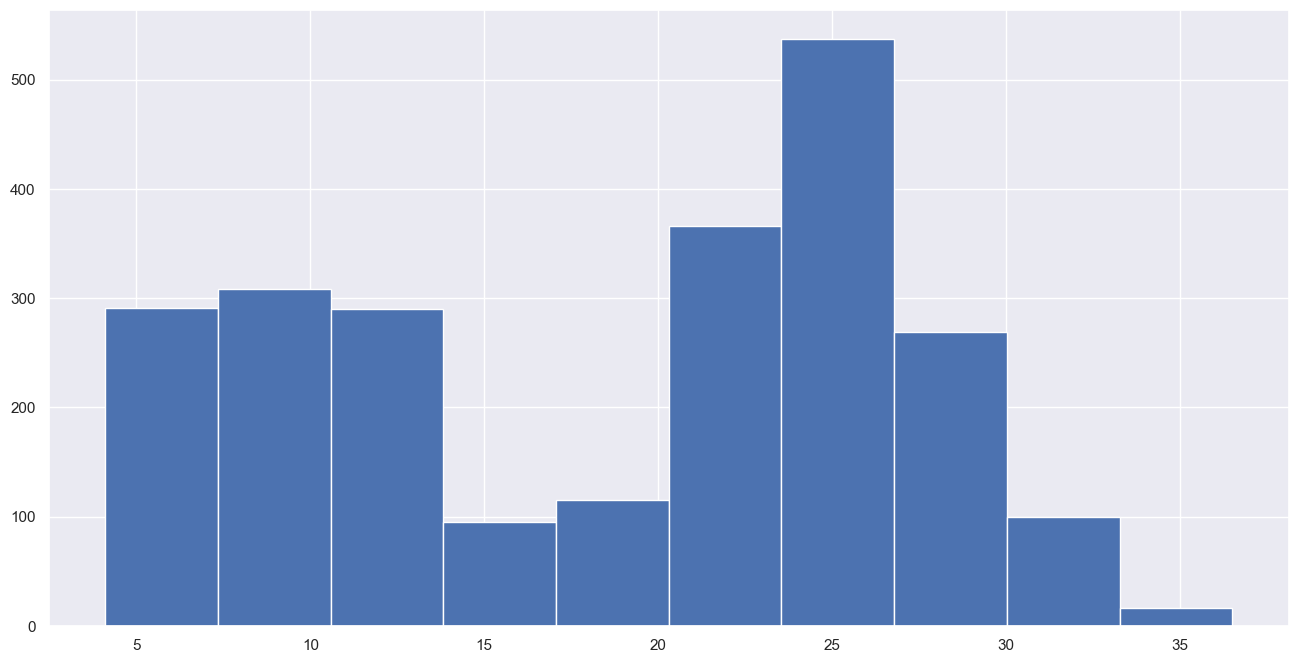

In [54]:
plt.hist(data1['Coolant_Temperature'], bins=10)

(array([ 32.,  95., 201., 367., 435., 511., 390., 227.,  97.,  32.]),
 array([37.6 , 39.58, 41.56, 43.54, 45.52, 47.5 , 49.48, 51.46, 53.44,
        55.42, 57.4 ]),
 <BarContainer object of 10 artists>)

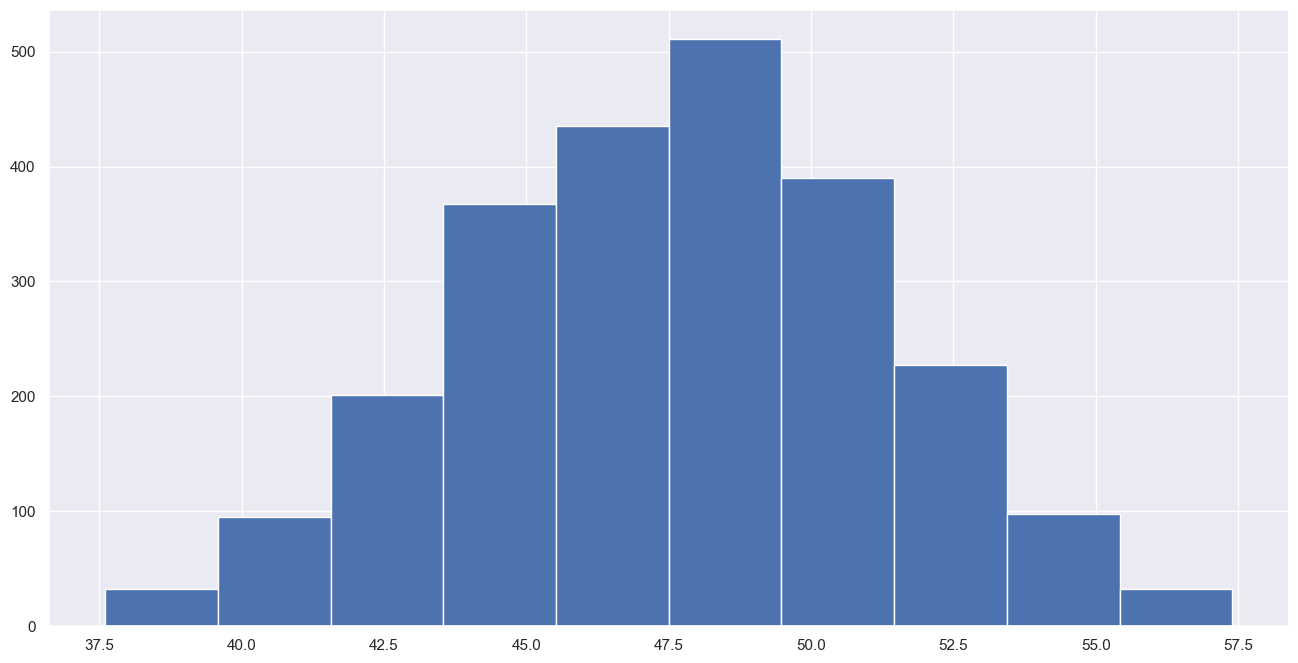

In [55]:
plt.hist(data1['Hydraulic_Oil_Temperature(°C)'], bins= 10)

(array([ 31.,  87., 207., 338., 500., 491., 405., 202.,  92.,  34.]),
 array([24.9 , 26.92, 28.94, 30.96, 32.98, 35.  , 37.02, 39.04, 41.06,
        43.08, 45.1 ]),
 <BarContainer object of 10 artists>)

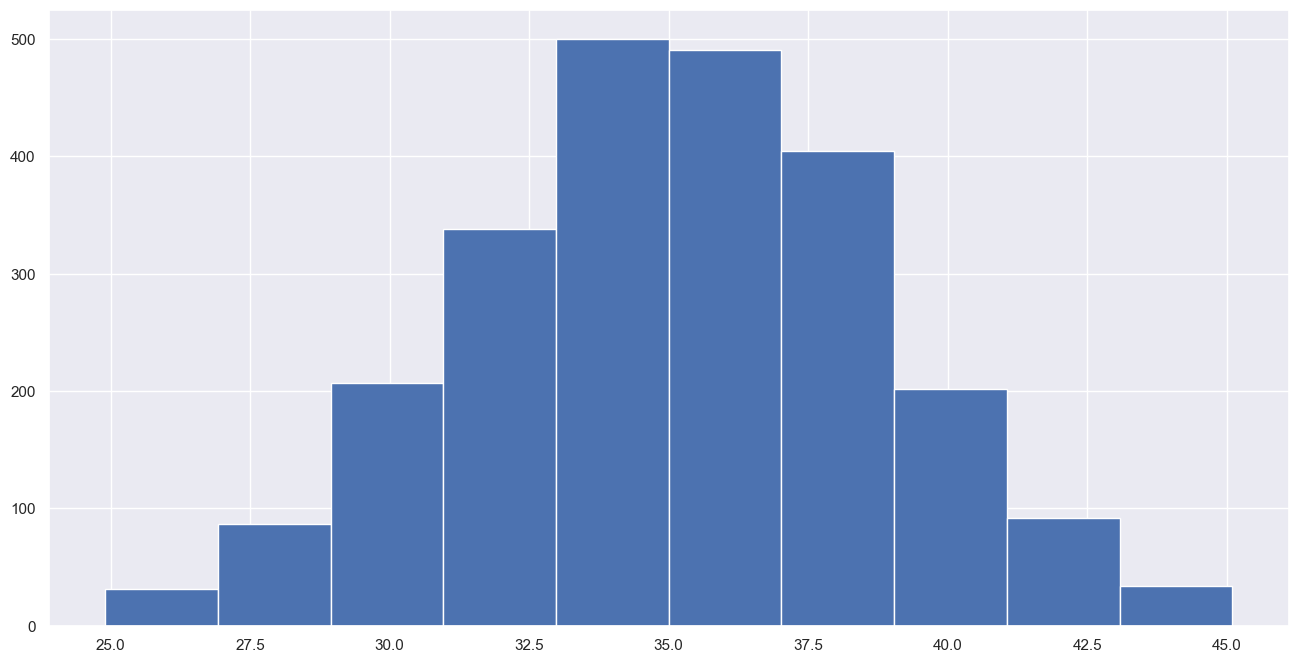

In [56]:
plt.hist(data1['Spindle_Bearing_Temperature(°C)'], bins=10)

C:\Users\Dell\AppData\Local\Temp\ipykernel_8948\3138727653.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data1['Spindle_Vibration(µm)'])


<AxesSubplot: xlabel='Spindle_Vibration(µm)', ylabel='Density'>

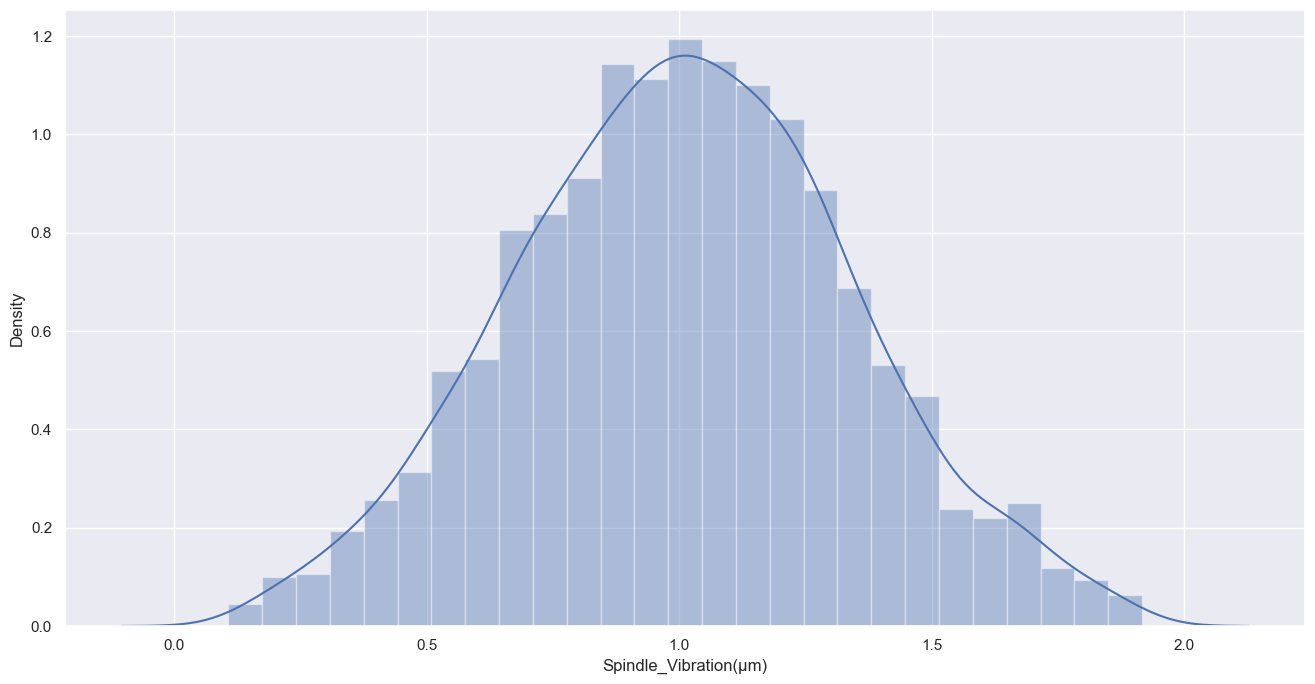

In [57]:
sns.distplot(data1['Spindle_Vibration(µm)'])

C:\Users\Dell\AppData\Local\Temp\ipykernel_8948\4232747399.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data1['Tool_Vibration(µm)'])


<AxesSubplot: xlabel='Tool_Vibration(µm)', ylabel='Density'>

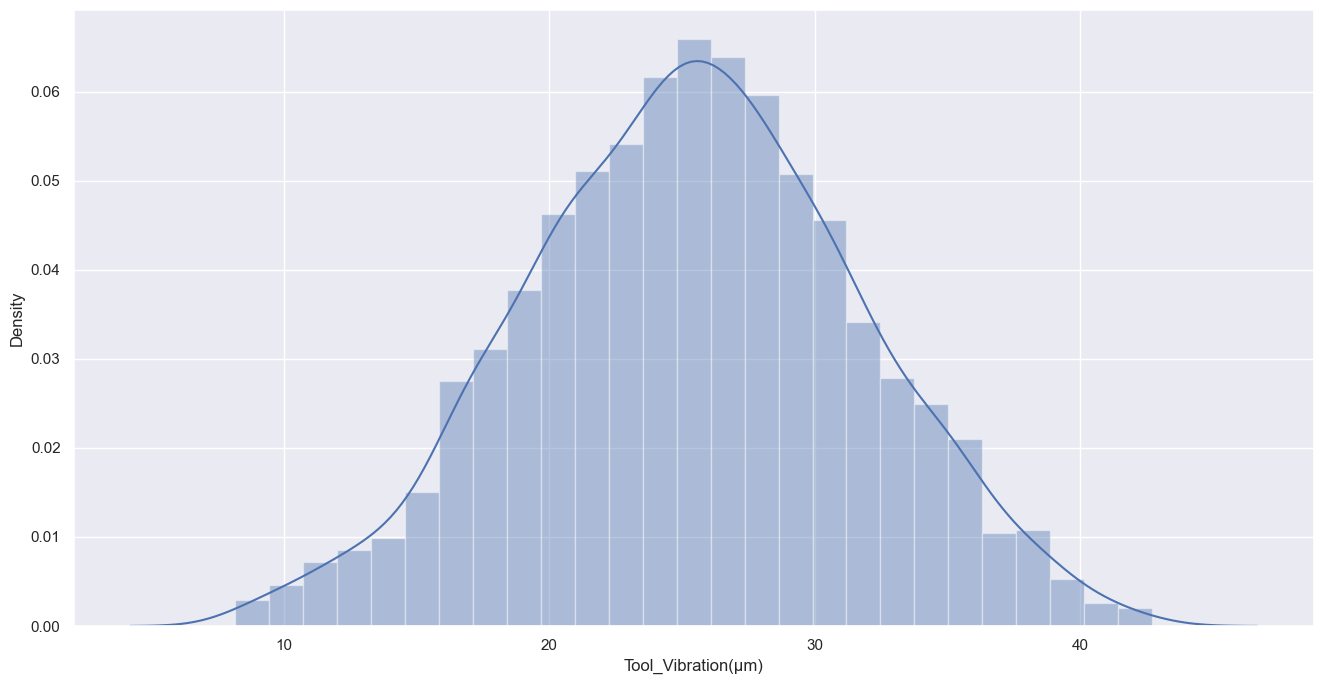

In [58]:
sns.distplot(data1['Tool_Vibration(µm)'])

C:\Users\Dell\AppData\Local\Temp\ipykernel_8948\2504846798.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data1['Spindle_Speed(RPM)'])


<AxesSubplot: xlabel='Spindle_Speed(RPM)', ylabel='Density'>

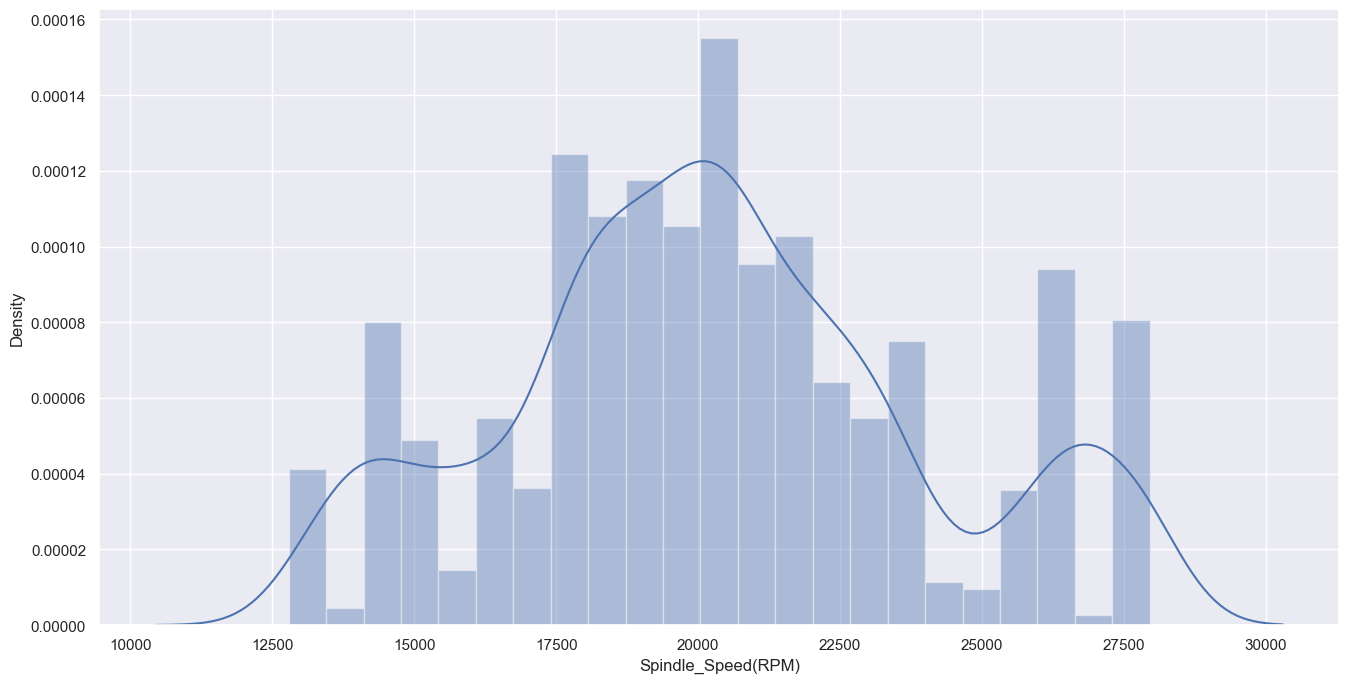

In [59]:
sns.distplot(data1['Spindle_Speed(RPM)'])

C:\Users\Dell\AppData\Local\Temp\ipykernel_8948\2609946967.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data1['Voltage(volts)'])


<AxesSubplot: xlabel='Voltage(volts)', ylabel='Density'>

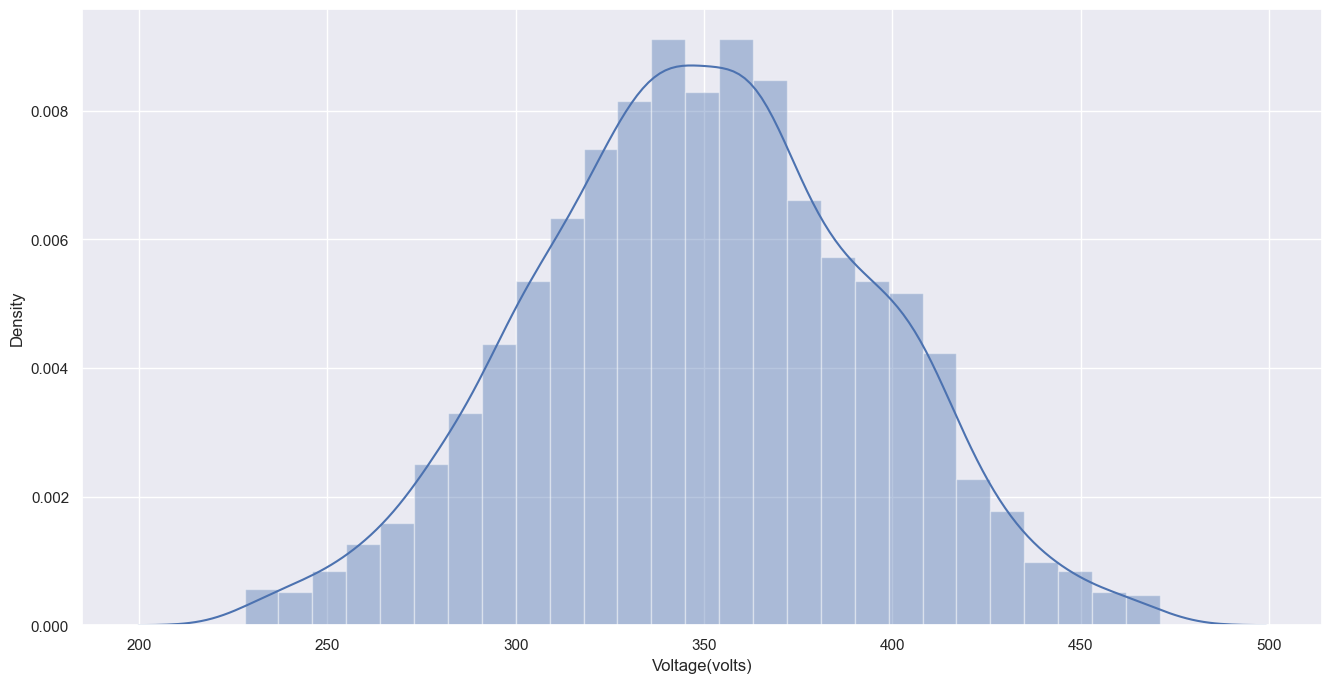

In [61]:
sns.distplot(data1['Voltage(volts)'])

C:\Users\Dell\AppData\Local\Temp\ipykernel_8948\1797912580.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data1['Torque(Nm)'])


<AxesSubplot: xlabel='Torque(Nm)', ylabel='Density'>

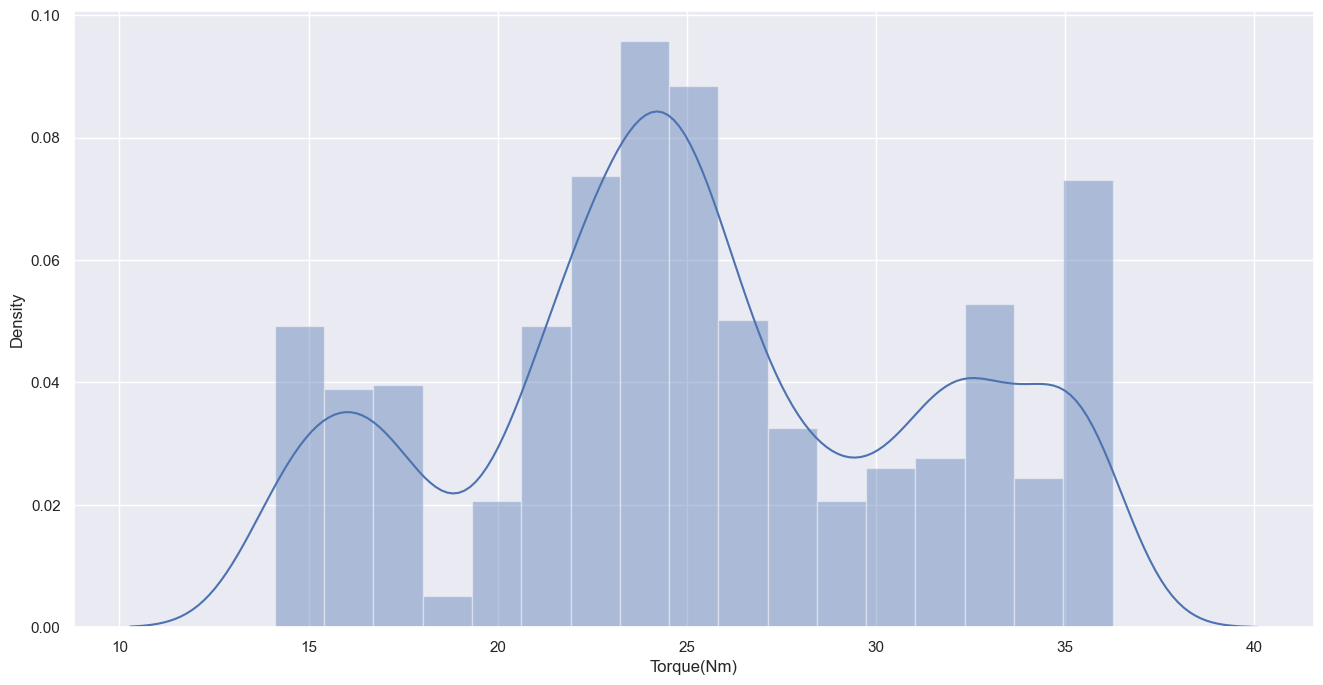

In [60]:
sns.distplot(data1['Torque(Nm)'])

C:\Users\Dell\AppData\Local\Temp\ipykernel_8948\2787692446.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data1['Cutting(kN)'])


<AxesSubplot: xlabel='Cutting(kN)', ylabel='Density'>

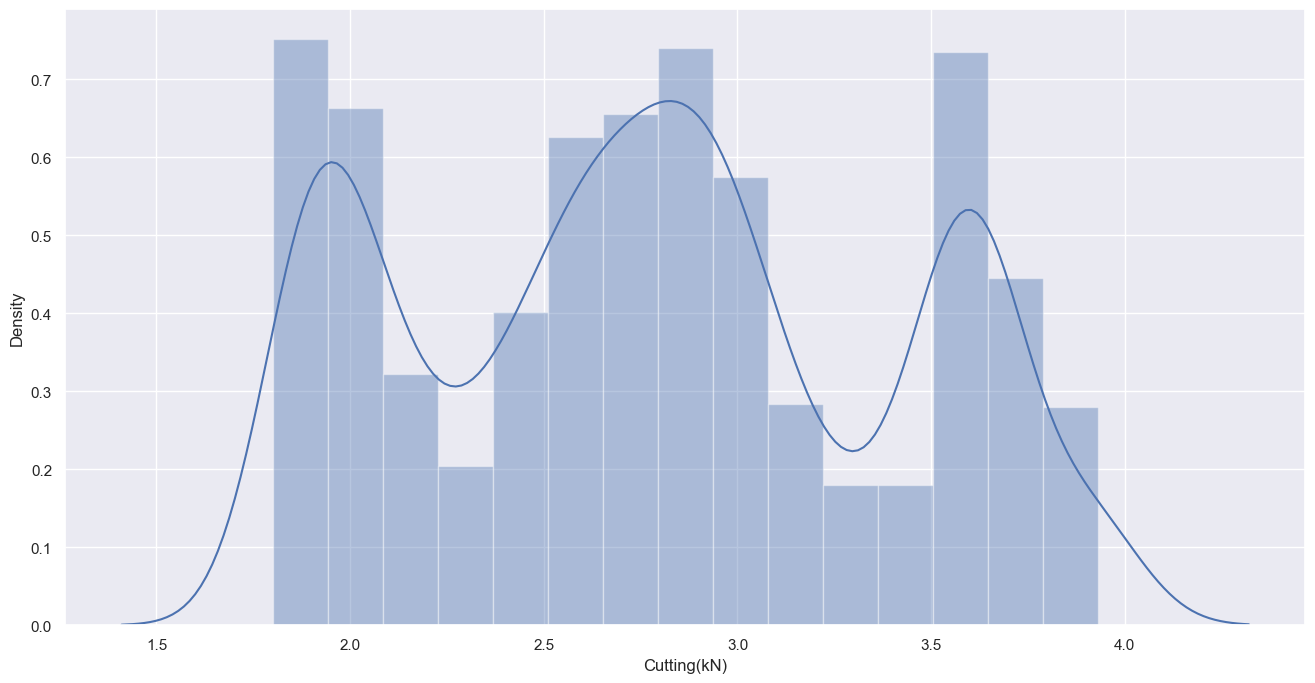

In [62]:
sns.distplot(data1['Cutting(kN)'])

(array([1205.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1182.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

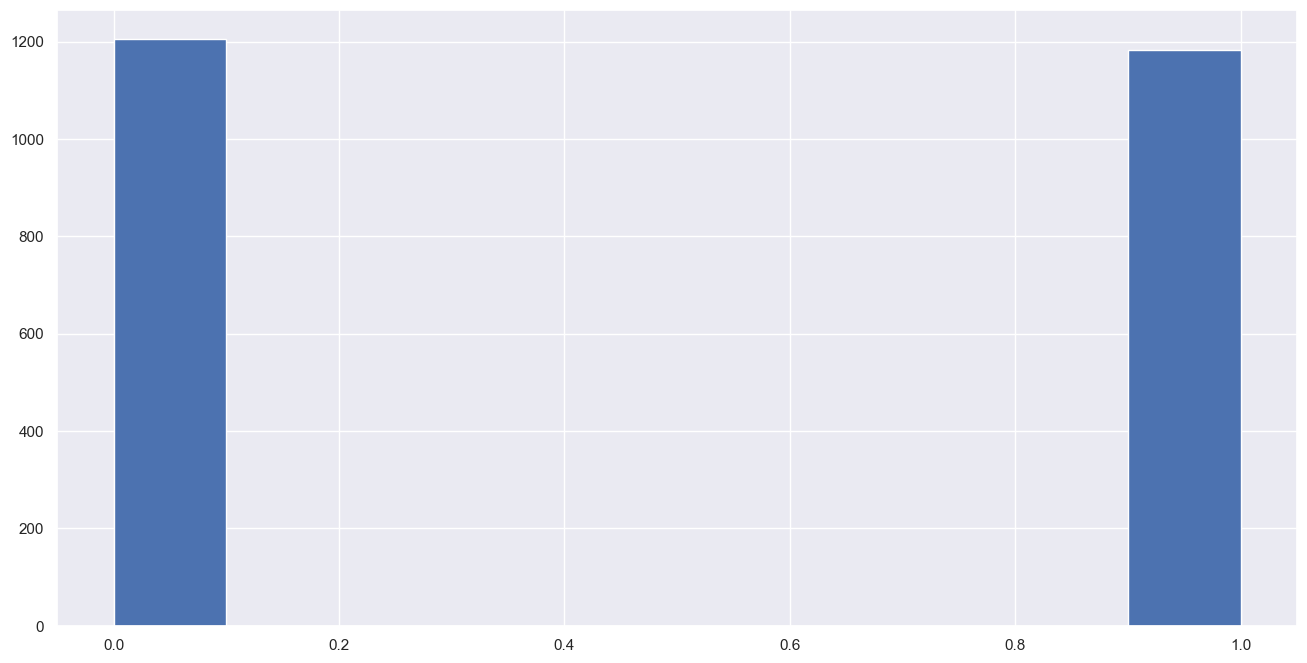

In [63]:
plt.hist(data1['Downtime'], bins=10)

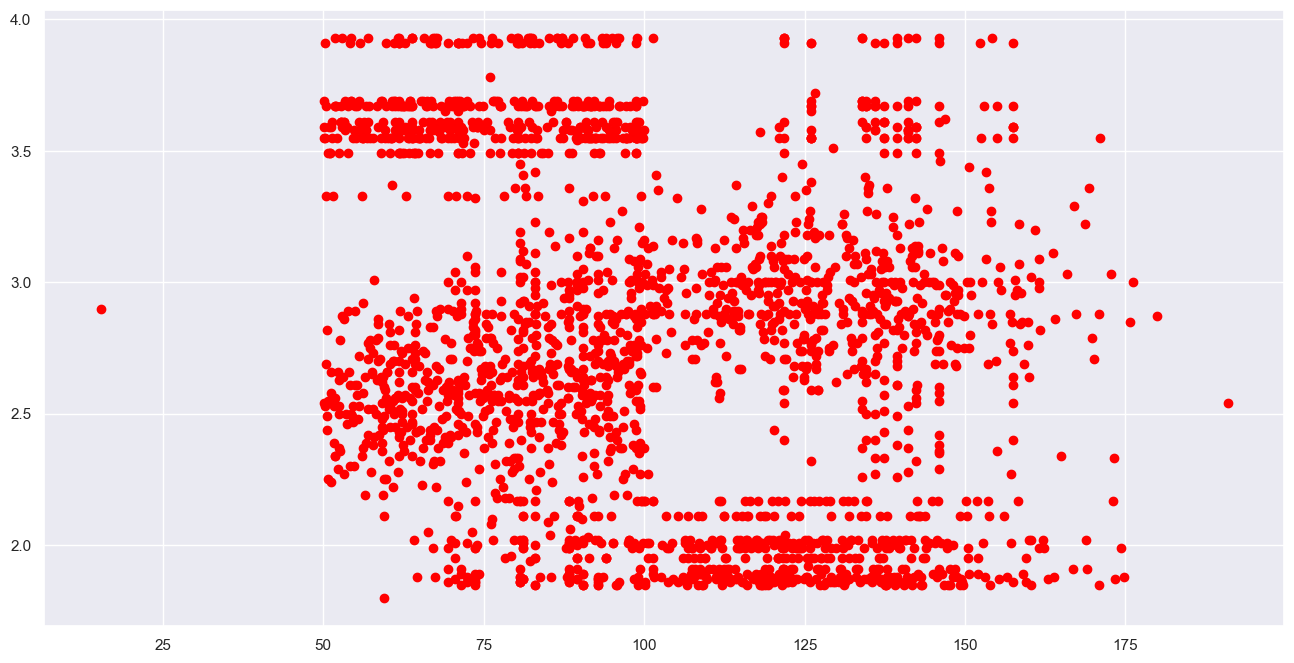

In [64]:
plt.scatter(data1['Hydraulic_Pressure(bar)'], data1['Cutting(kN)'], c ='red')

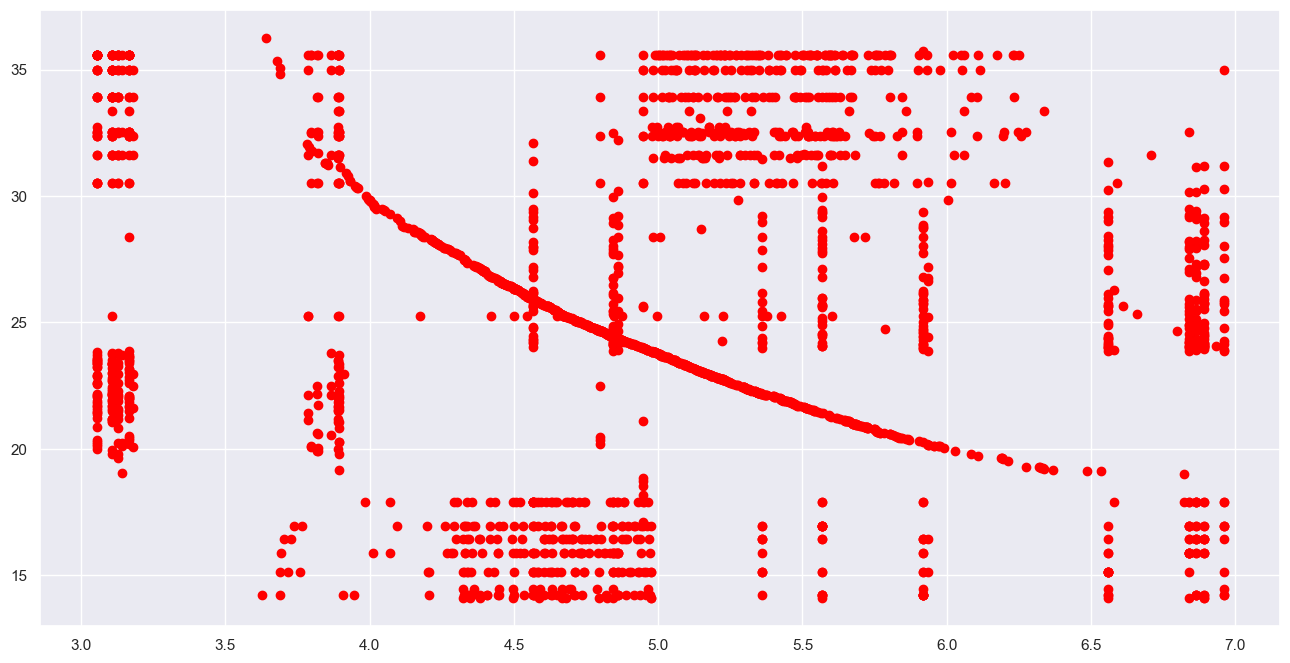

In [65]:
plt.scatter(data1['Coolant_Pressure(bar)'], data1['Torque(Nm)'], c ='red')

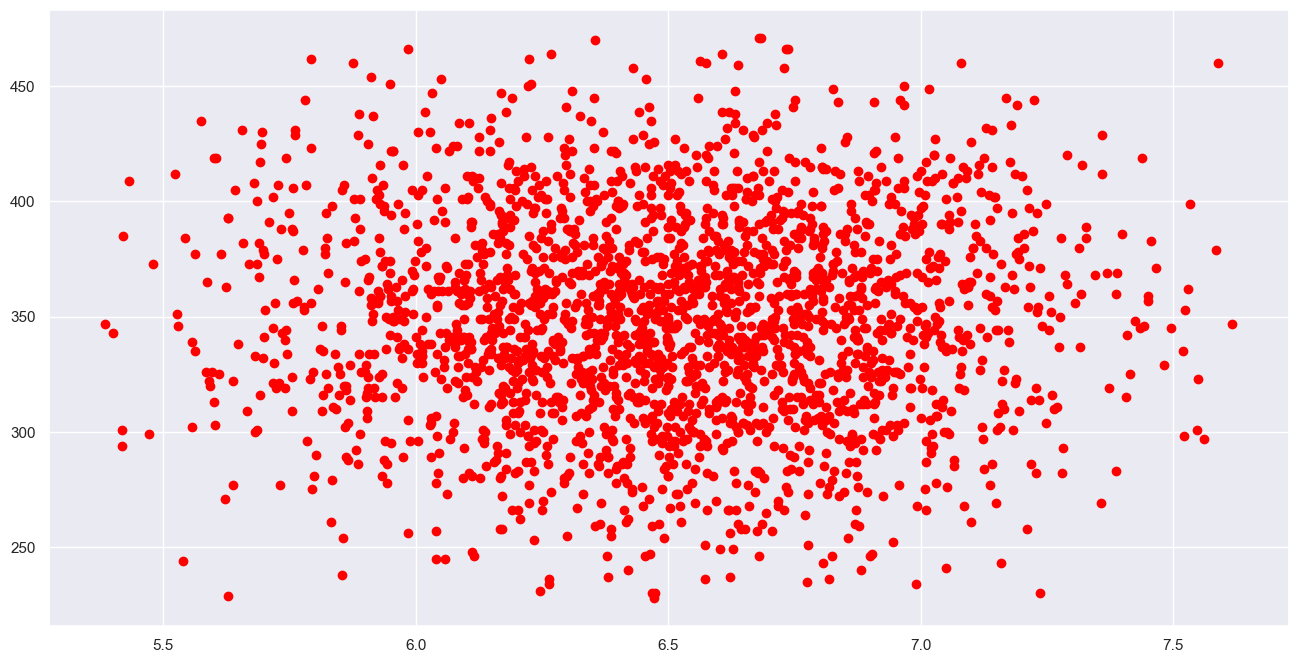

In [66]:
plt.scatter(data1['Air_System_Pressure(bar)'], data1['Voltage(volts)'], c ='red')

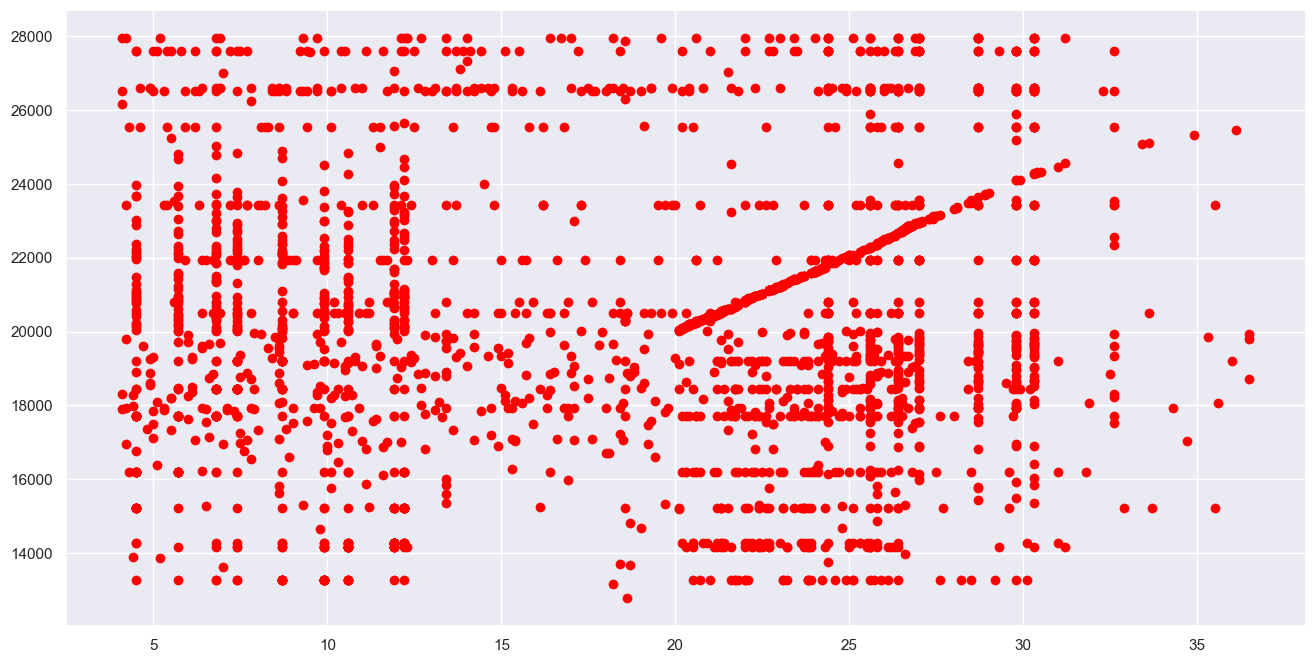

In [67]:
plt.scatter(data1['Coolant_Temperature'], data1['Spindle_Speed(RPM)'], c ='red')

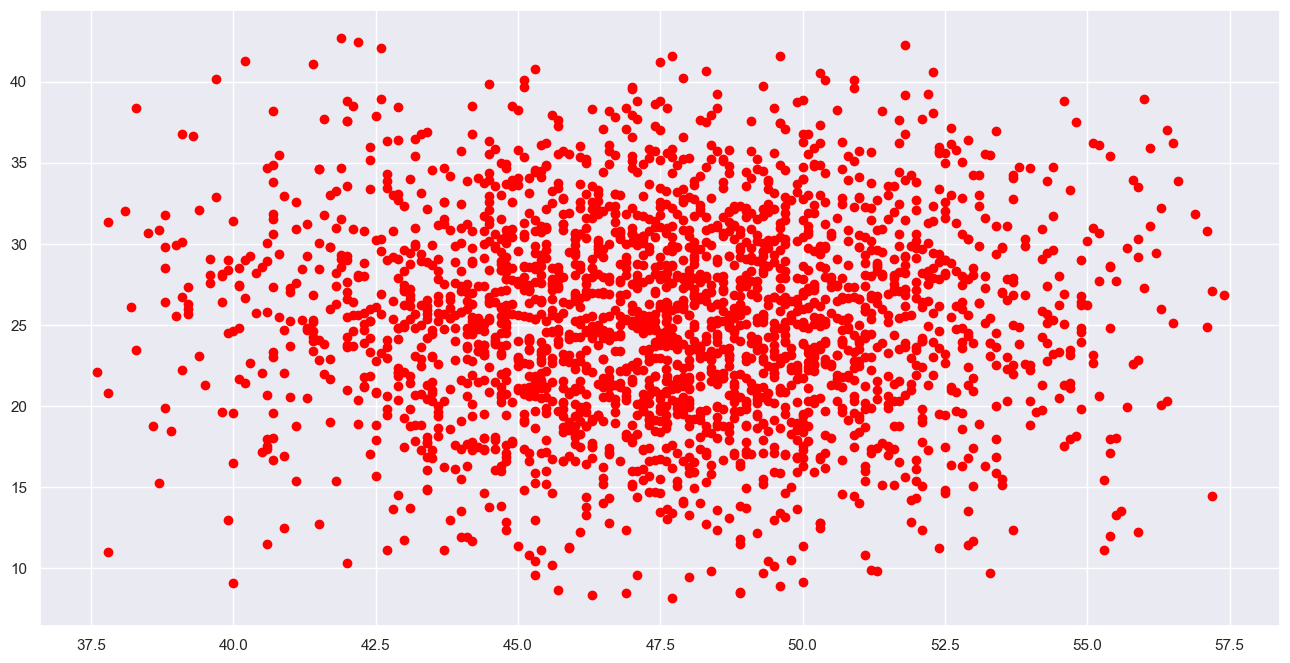

In [68]:
plt.scatter(data1['Hydraulic_Oil_Temperature(°C)'], data1['Tool_Vibration(µm)'], c ='red')

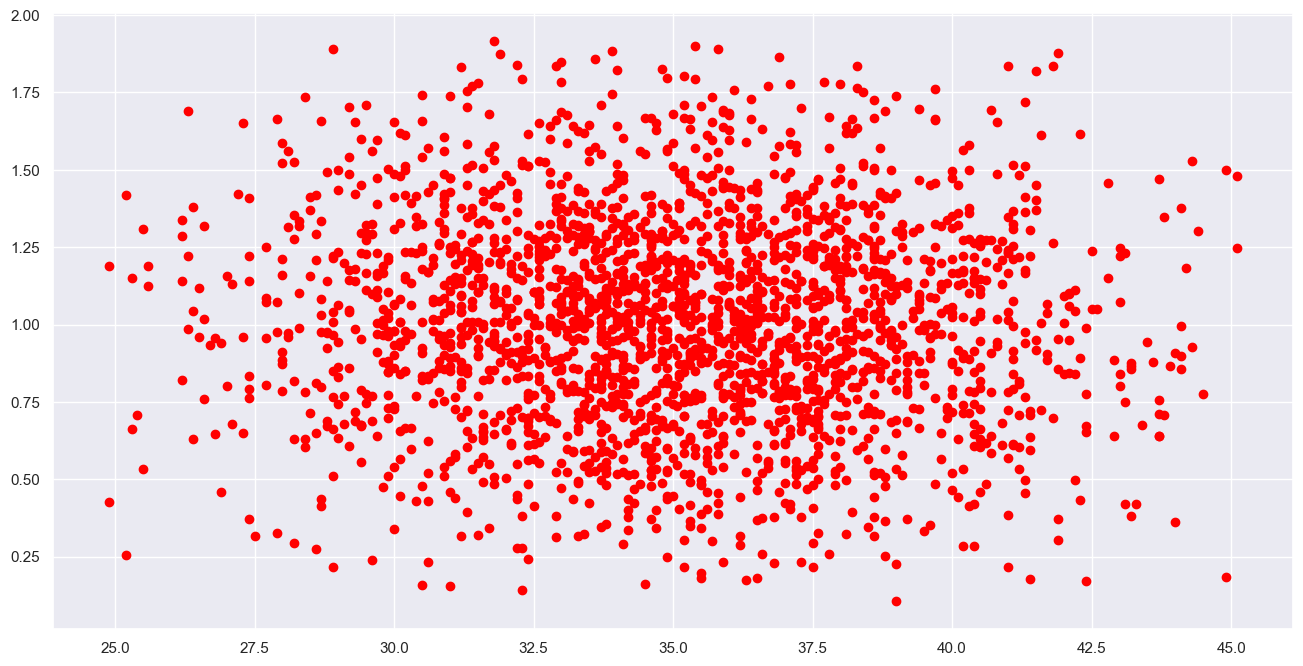

In [69]:
plt.scatter(data1['Spindle_Bearing_Temperature(°C)'], data1['Spindle_Vibration(µm)'], c ='red')